# Instrução do Projeto

A Film Junky Union, uma nova comunidade para entusiastas de filmes clássicos, está desenvolvendo um sistema para filtrar e categorizar resenhas de filmes. O objetivo é treinar um modelo para detectar automaticamente resenhas negativas. Você usará um conjunto de dados de resenhas de filmes do IMDB com rotulagem de polaridade para criar um modelo para classificar resenhas como positivas e negativas. Ele precisará ter um valor F1 de pelo menos 0,85.

## Inicialização

In [8]:
# importação das bibliotecas

import math
import time

import numpy as np
import pandas as pd
import re

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

import sklearn.metrics as metrics
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

import nltk
from nltk.corpus import stopwords

import spacy

from lightgbm import LGBMClassifier

import torch
import transformers
from transformers import BertTokenizer

In [6]:
# renderizar os gráficos diretamente abaixo da célula
%matplotlib inline

# define os gráficos de melhor qualidade em telas HiDPI
%config InlineBackend.figure_format = 'retina'

# define estética visual dos gráficos
plt.style.use('seaborn-v0_8-darkgrid')

# comando "ensina" pandas a conversar com a biblioteca tqdm (usar progress_aply: barra de progresso)
tqdm.pandas()   

## Carregar Dados

In [13]:
# carregar dados

try:
    df_reviews = pd.read_csv('imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})
    print(f"✅ Arquivo carregado com sucesso!")
    print('=' * 60)
    print(f"🔍  Visualização das Primeiras Linhas do Dataframe")
    print('=' * 60)
    display(df_reviews.head())
    print('=' * 60)
    print(f"📐 Dimensões do DataFrame")
    print('=' * 60)
    print(f"Número de Linhas: {df_reviews.shape[0]}")
    print(f"Número de Colunas: {df_reviews.shape[1]}")
except Exception as e:
    print(f"❌ Erro na leitura do arquivo. Detalhes: {e}")

✅ Arquivo carregado com sucesso!
🔍  Visualização das Primeiras Linhas do Dataframe


,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


📐 Dimensões do DataFrame
Número de Linhas: 47331
Número de Colunas: 17


In [14]:
print('=' * 60)
print(f"ℹ️ Informações Gerais do Dataframe")
print('=' * 60)
print(df_reviews.info())

ℹ️ Informações Gerais do Dataframe
<class 'pandas.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  str    
 1   title_type       47331 non-null  str    
 2   primary_title    47331 non-null  str    
 3   original_title   47331 non-null  str    
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  str    
 6   runtime_minutes  47331 non-null  str    
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  str    
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  str    
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  str    
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  str    
 16  idx              47331 non-null  i

In [15]:
print('=' * 60)
print(f"📊 Estatísticas Descritivas do DataFrame")
print('=' * 60)
print(df_reviews.describe())

📊 Estatísticas Descritivas do DataFrame
         start_year      is_adult  average_rating         votes        rating  \
count  47331.000000  47331.000000    47329.000000       47329.0  47331.000000   
mean    1989.631235      0.001732        5.998278  25562.917323      5.484608   
std       19.600364      0.041587        1.494289  83670.039163      3.473109   
min     1894.000000      0.000000        1.400000           9.0      1.000000   
25%     1982.000000      0.000000        5.100000         827.0      2.000000   
50%     1998.000000      0.000000        6.300000        3197.0      4.000000   
75%     2004.000000      0.000000        7.100000       13974.0      9.000000   
max     2010.000000      1.000000        9.700000     1739448.0     10.000000   

                pos           idx  
count  47331.000000  47331.000000  
mean       0.498954   6279.697999  
std        0.500004   3605.702545  
min        0.000000      0.000000  
25%        0.000000   3162.000000  
50%        0.0

In [16]:
# --- Tratamento para Valores Ausentes ---

# exclusão de valores ausentes nas colunas 'votes' e 'average_rating'
print(f"Dimensões antes: {len(df_reviews)}")
null_counts = df_reviews[['votes', 'average_rating']].isna().sum()
percent_null = (null_counts / len(df_reviews)) * 100
print(f"Quantidade de valores nulos: {null_counts.values[0]}")
print(f"Representatividade de valores nulos antes do dropna(): {percent_null.values[0]:.3f}%")
df_reviews = df_reviews.dropna(subset=['votes', 'average_rating'])
print('-' * 65)
print(f"Dimensões depois: {len(df_reviews)}")
print(f"O dataset possui {df_reviews.isna().sum().sum()} valores ausentes após dropna()")

Dimensões antes: 47331
Quantidade de valores nulos: 2
Representatividade de valores nulos antes do dropna(): 0.004%
-----------------------------------------------------------------
Dimensões depois: 47329
O dataset possui 0 valores ausentes após dropna()


In [17]:
# --- Análise de Valores Únicos ---

# loop para verificar valores únicos em cada coluna
cols_to_check = ['title_type', 'start_year', 'runtime_minutes', 'is_adult', 'genres', 'votes', 'rating', 'sp', 'pos', 'ds_part']

for col in cols_to_check:
    print(f"--- Coluna {col}: ---")
    print(f"Quantidade de valores únicos: {df_reviews[col].nunique()}")
    print(f"Top 10 valores mais frequentes:")
    print(df_reviews[col].value_counts().head(10))
    print("\n" + "=" * 60 + "\n")

--- Coluna title_type: ---
Quantidade de valores únicos: 10
Top 10 valores mais frequentes:
title_type
movie           36859
tvMovie          2892
video            2742
tvSeries         2246
short             887
tvMiniSeries      713
tvEpisode         635
tvSpecial         183
videoGame         154
tvShort            18
Name: count, dtype: int64


--- Coluna start_year: ---
Quantidade de valores únicos: 107
Top 10 valores mais frequentes:
start_year
2006    3275
2005    3076
2003    2355
2004    2228
2000    2108
2007    2106
2002    2071
2001    1912
1999    1813
1998    1377
Name: count, dtype: int64


--- Coluna runtime_minutes: ---
Quantidade de valores únicos: 249
Top 10 valores mais frequentes:
runtime_minutes
90     2442
95     1820
100    1420
92     1418
93     1311
96     1261
91     1226
85     1189
88     1179
94     1115
Name: count, dtype: int64


--- Coluna is_adult: ---
Quantidade de valores únicos: 2
Top 10 valores mais frequentes:
is_adult
0    47247
1       82
Name:

In [18]:
# --- Verificação de Colunas Duplicadas ---

# verificação se as colunas 'sp' e 'pos' são idênticas
df_reviews['sp_binary'] = df_reviews['sp'].map({'neg': 0, 'pos': 1})
# conferência se 'sp' mapeado é igual a 'pos'
check = ((df_reviews['sp_binary']) == df_reviews['pos']).all()
print(f"As colunas sp e pos são idênticas? {check}")

As colunas sp e pos são idênticas? True


**Conclusões Iniciais**

`Limpeza e Padronização dos Dados:`'
- **Dados Analisados e Considerados Adequados:** nomenclatura das colunas.
- **Valores Ausentes:** valores ausentes em quantidade não significativa foram excluídos do dataset (0.004%)
- **Balanceamento de Classes ('pos' = Target):** a média 0.49 (~ 50%) na estatística descritiva sugere balanceamento entre as classes positiva vs negativa. Pravável que não haja necessidade de aplicar técnicas de balancemento.
- **Período**: os filmes avaliados estão datados entre 1894 e 2010, implicam em vocabulários específicos usados para cada época.

`Distribuição dos Dados`:
- **title_type**: categoria dominada pelo tipo 'movie'.
- **star_year**: os anos com maior quantidade de registros estão entre 1998 e 2006.
- **runtima_minutes**: maior quantidade de registros de filmes entre 85 e 100 minutos.
- **is_adult**: expressiva quantidade de filmes não adultos (47.247 vs 82), coluna quase não tem variância e deve ser descartada para treinamento do modelo.
- **genres**: os gêneros podem ser combinados, dentro do top 10, 'Drama' é a categoria que mais aparece.
- **rating**: as classificações 5 e 6 não aparecem no dataset. Os clientes tendem a classificações extremas, 1 e 10 são as pontuações mais frequentes.
- **sp e pos**: colunas com informações idênticas. A coluna 'sp' não deverá ser usada no treinamento do modelo. Observado balanceamento ideal da target (23.715 vs 23.614).
- **ds_part**: resultado balanceado de treinamento e teste (23.796 vs 23.533)

## AED

Vamos verificar o número de filmes e resenhas ao longo dos anos.

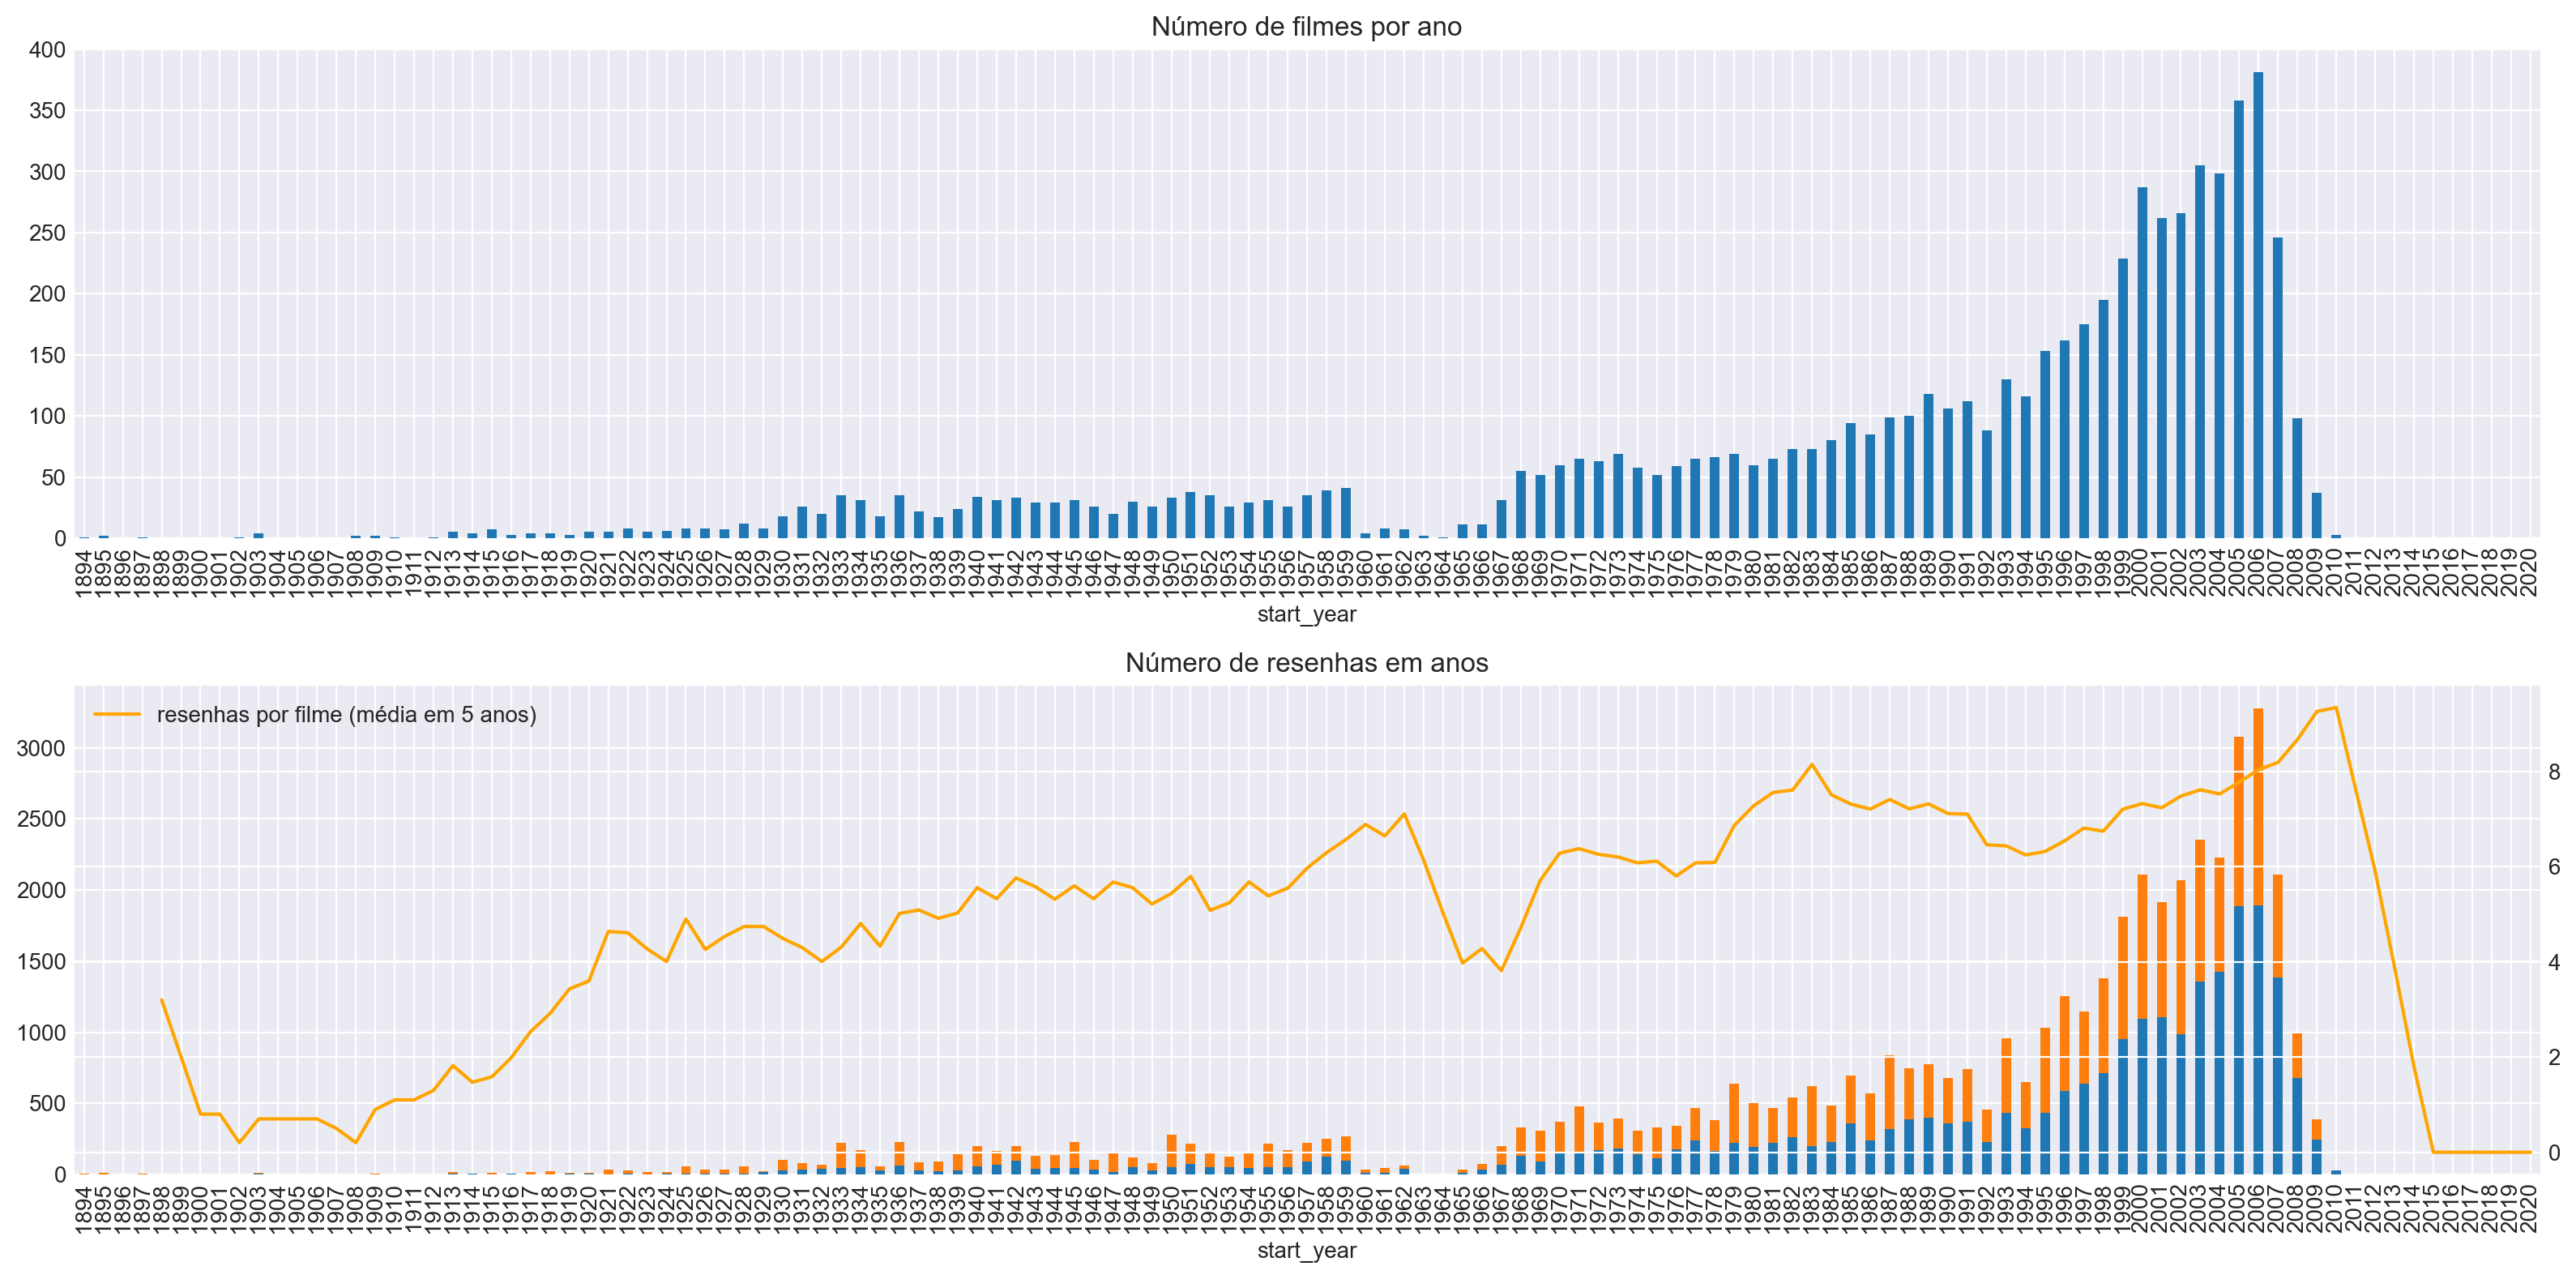

In [20]:
# análise temporal: número de filmes e resenhas por ano
# configuração dos gráficos
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

# contagem de filmes por ano, preenchendo anos sem filmes com valor zero e ordenando por ano
dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de filmes por ano')

ax = axs[1]

# agrupamento por ano e sentimento (target='pos'), conta e usa .unstack() para transformar os sentimentos em colunas
dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)
dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

# divisão do total de resenhas pelo total de filmes por ano, preenchendo anos sem filmes com valor zero e ordenando por ano
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
# aplicação de média móvel em 5 anos
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='resenhas por filme (média em 5 anos)', ax=axt)

# ajustes finais de legenda e layout
lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')
ax.set_title('Número de resenhas em anos')

fig.tight_layout()

Vamos verificar a distribuição do número de resenhas por filme com a contagem exata e o EDK (Estimativa de densidade kernel para saber como pode diferir da contagem exata)

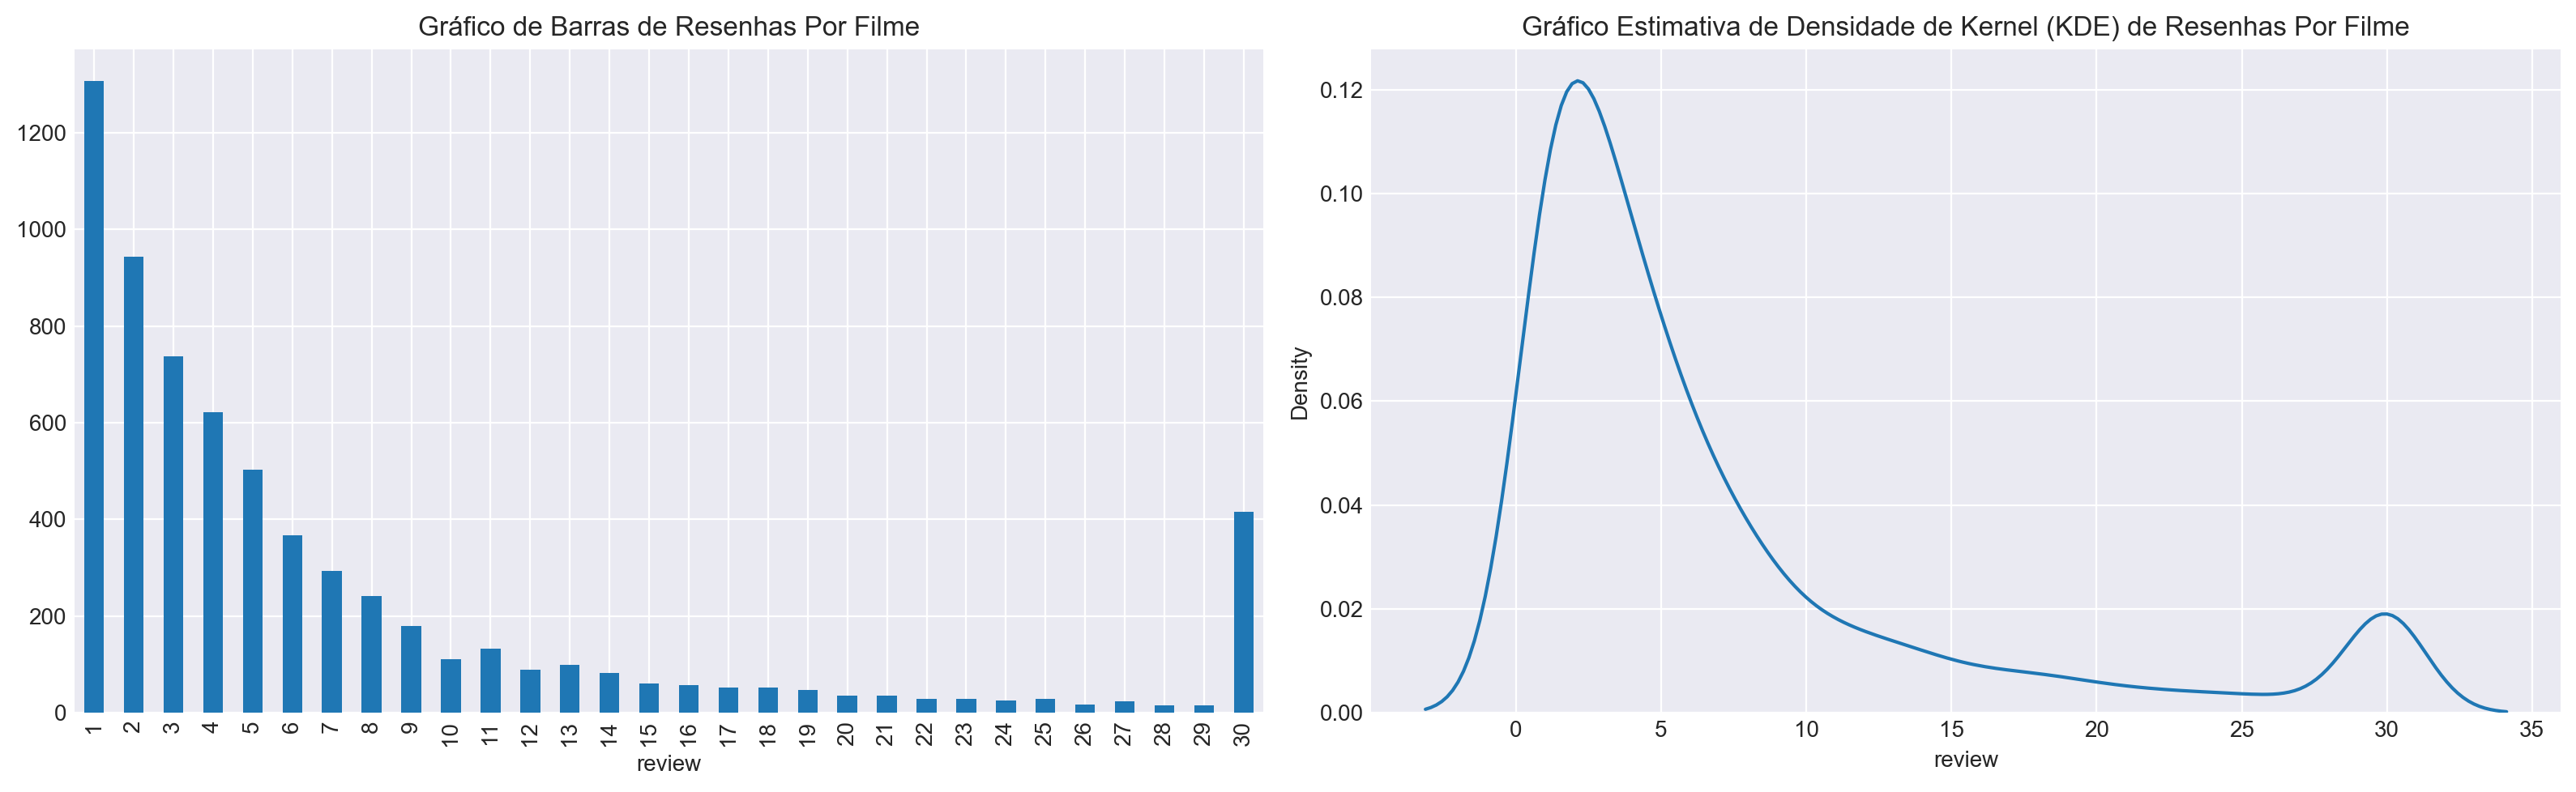

In [21]:
# análise de distribuição: quantidade de resenhas por filme
# configuração dos gráficos
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]

# agrupamento de resenhas por filme, contagem do quantitativo de resenhas por filme, ordenando por quantidade de resenhas
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Gráfico de Barras de Resenhas Por Filme')

ax = axs[1]

# agrupamento de resenhas por filme, contagem do quantitativo de resenhas por filme
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Gráfico Estimativa de Densidade de Kernel (KDE) de Resenhas Por Filme')

fig.tight_layout()

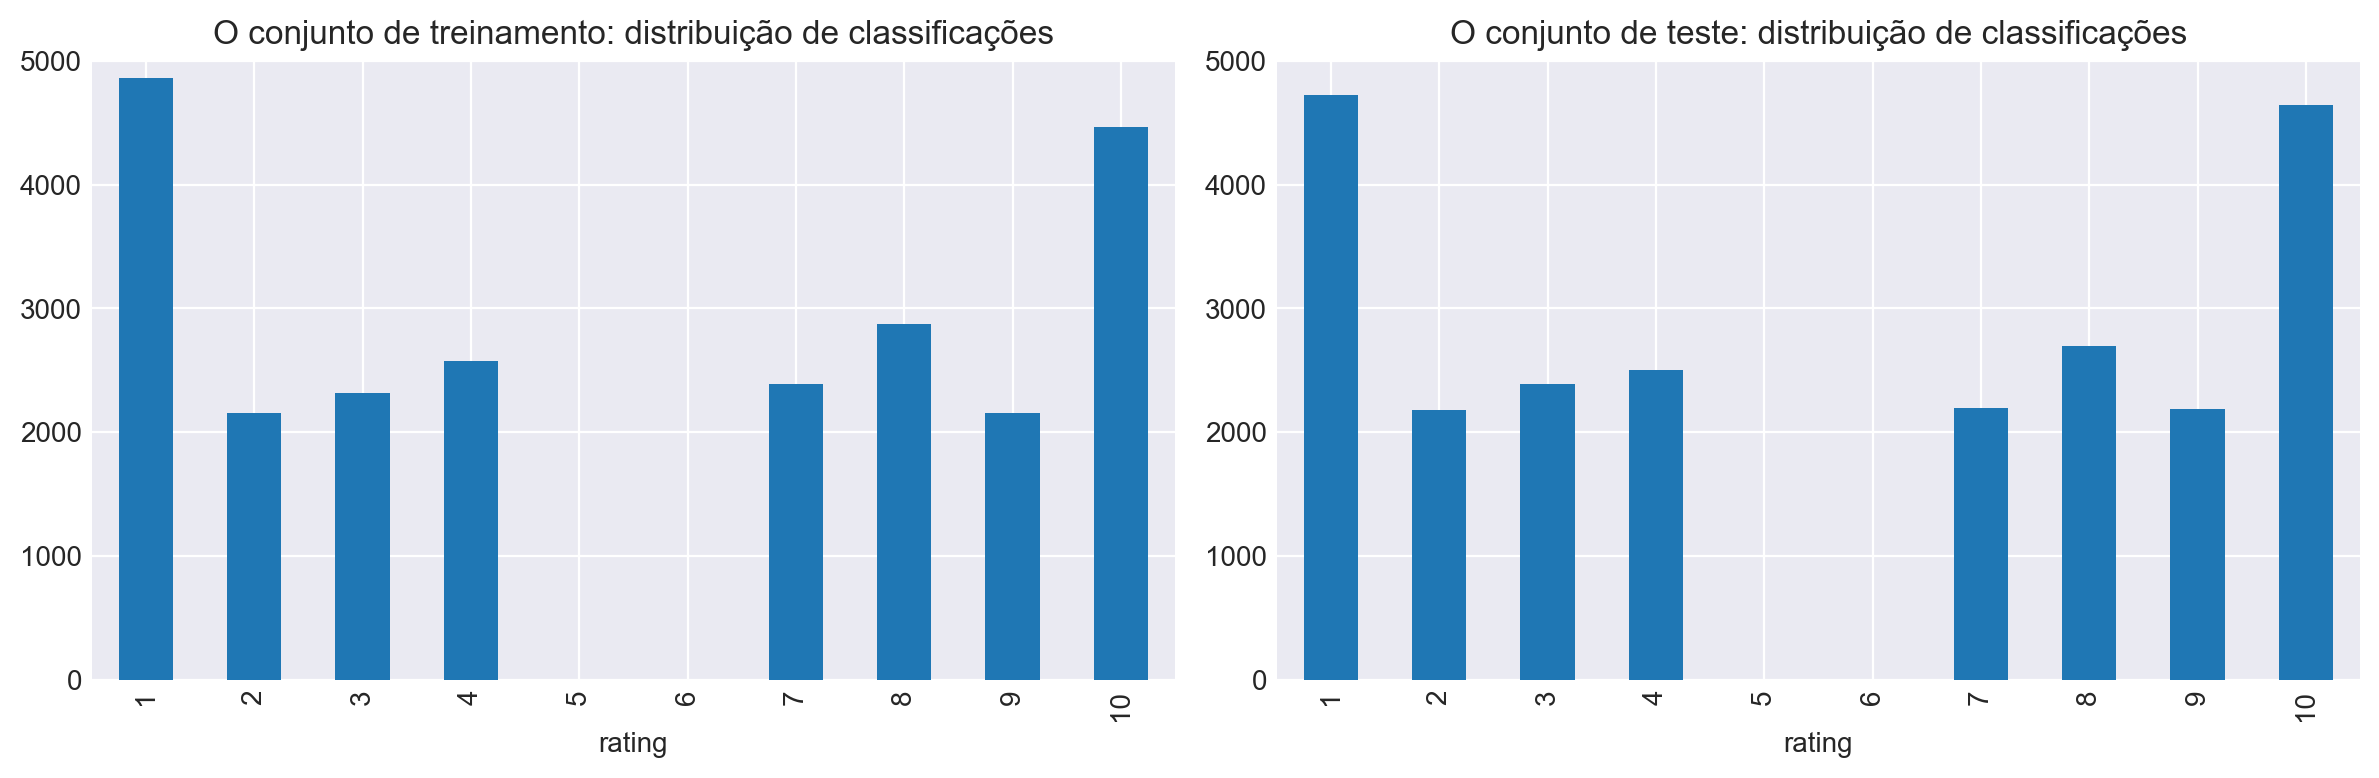

In [23]:
# análise de distribuição: quantidade de resenhas por classificação (rating)
# configuração dos gráficos
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]

# cotntagem de resenhas do conjunto de treinamento por classificação, preenchendo com zero onde não houver resenhas
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de treinamento: distribuição de classificações')

ax = axs[1]

# contagem de resenhas do conjunto de teste por classificação, preenchendo com zero onde não houver resenhas
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de teste: distribuição de classificações')

fig.tight_layout()

Distribuição de resenhas negativas e positivas ao longo dos anos para duas partes do conjunto de dados

C:\Users\galli\AppData\Local\Temp\ipykernel_3612\323660846.py:18: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
C:\Users\galli\AppData\Local\Temp\ipykernel_3612\323660846.py:19: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
C:\Users\galli\AppData\Local\Temp\ipykernel_3612\323660846.py:36: UserWarning: 

Support for alternate kernels has been removed; using Gaussian kernel.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
C:\Users\galli\AppData\Local\Temp\ipykernel_3612\323660846.py:37: UserWarning: 

Support for alternate

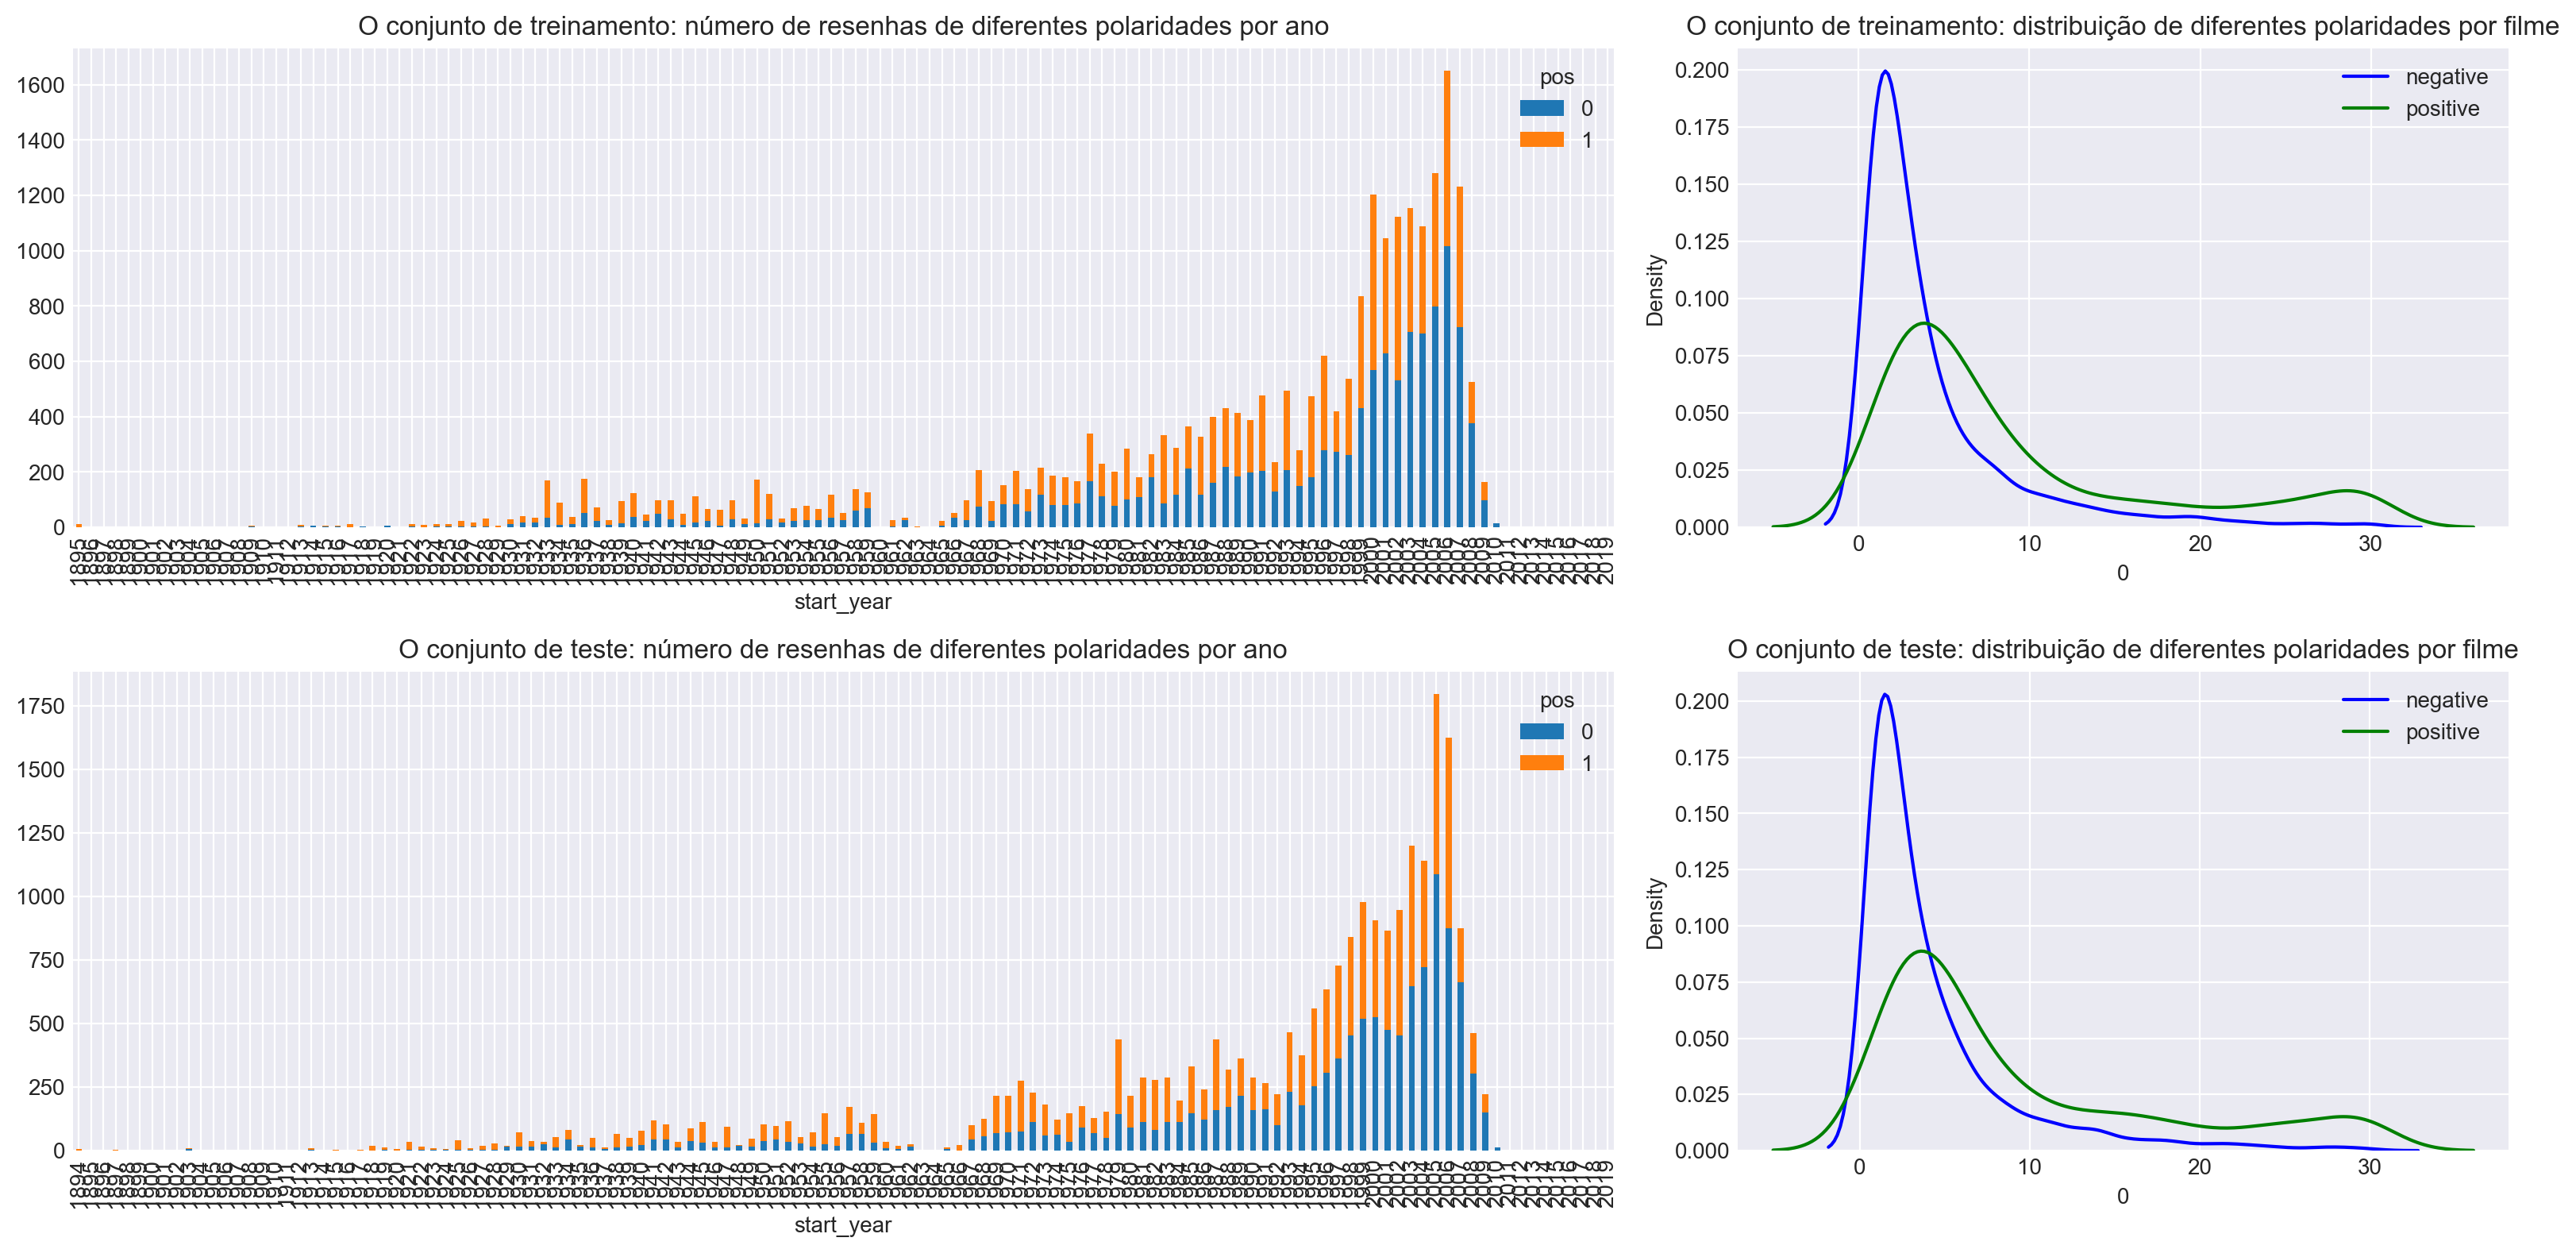

In [24]:
# análise de distribuição: quantidade de resenhas por polaridade (sentimento) ao longo dos anos
# configuração dos gráficos
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

# agrupamento dos dados de treinamento por ano e sentimento ('pos'), preenchendo anos sem resenhas com valor zero e ordenando por ano
dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de treinamento: número de resenhas de diferentes polaridades por ano')

ax = axs[0][1]

# agrupamento dos dados de treinamento por filme e sentimento ('pos'), preenchendo filmes sem resenhas com valor zero
dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('O conjunto de treinamento: distribuição de diferentes polaridades por filme')

ax = axs[1][0]

# agrupamento dos dados de teste por ano e sentimento ('pos'), preenchendo anos sem resenhas com valor zero e ordenando por ano
dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de teste: número de resenhas de diferentes polaridades por ano')

ax = axs[1][1]

# agrupamento dos dados de teste por filme e sentimento ('pos'), preenchendo filmes sem resenhas com valor zero
dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('O conjunto de teste: distribuição de diferentes polaridades por filme')

fig.tight_layout()

**Conclusões sobre os Gráficos: Etapa EAD**

`Análise Temporal: número de filmes e resenhas por ano`
- Identificou-se o aumento de linear de registros a partir dos anos 1990, atingindo o pico entre 2003 e 2006. Risco de viés: tendência a performar melhor em filmes modernos, e o vocabulário das resenhas dos anos 2000 dominará o treinamento em relação a linguagem das resenhas dos filmes da décade de 1930.
- Observou-se lacuna temporal com pouca quantidade de filmes e resenhas no início da década de 60, que coincide com o período da segunda guerra mundial. A falta de exemplos neste período pode implicar em queda de acurácia. Há também ausência de filmes a partir do anos 2010. 
- Apesar de termos menor quantidade de filmes antigos, o engajamento médio (resenhas por filme) em certos períodos clássicos (como as décadas de 50 e 80) é comparável ou até superior aos anos 2000 em termos de densidade por título.

`Análise de Distribuição: quantidade de resenhas por filme`
- A análise de densidade mostra que a base de dados é composta em sua maioria por filmes com baixa contagem de resenhas, seguindo uma distribuição de cauda longa.
- Observou-se um limite máximo de 30 resenhas por título, característica garante que o modelo seja exposto a uma grande variedade de obras cinematográficas, evitando que o treinamento seja dominado por um pequeno grupo de filmes excessivamente comentados.

`Análise de Distribuição: quantidade de resenhas por classificação (rating)`
- As classificações estão idênticas entre o conjunto de treinamento e de teste, garantindo a integridade da validação cruzada.
- Não há classificações intermediárias (5 e 6), portanto, os dados do dataset foram filtrados para ter classificações polarizadas, eliminando ambiguidades (neutralidade) que poderiam impactar negativamente no F1-score.
- Os clientes tendem a classificação extrema (1 e 10), sugerindo que o vocabulário contido nestas resenhas conterá adjetivos intensos, favorecendo a captação das características (features) para o modelo.
- As demais classificações estão equilibradas, o que exigirá atenção para as resenhas que se utilizem de sarcasmo ou críticas sutis.

`Análise de Distribuição: quantidade de resenhas por polaridade (0 ou 1)`
- Em ambos os gráficos, os resultados para o conjunto de treinamento e de teste são idênticos, garantindo a consistência para a avaliação do modelo.
- Análise Temporal da Distribuição das Polaridades por ano: há balanceamento estável entre as resenhas positivas e negativas ao longo dos anos, impedindo viéses relacionado às épocas no treinamento.
- Análise de Ditribuição das polaridades por filme: as resenhas negativas mostram maior concentração em filmes com baixo volume de críticas (pico íngrime < 5). Já as resenhas positivas distribuem-se de forma mais suave, sugerindo que o engajamento positivo é mais distribuído entre diferentes volumes de resenhas por filme.

## Procedimento de Avaliação

Compondo uma rotina de avaliação que pode ser utilizada para todos os modelos deste projeto

In [25]:
# função para avaliação dos modelos

def evaluate_model(model, train_features, train_target, test_features, test_target, model_name):
    '''
    Avalia o desempenho de um modelo de machine learning.

    Parâmetros:
    - model: o modelo de machine learning a ser avaliado
    - train_features: as características do conjunto de dados de treinamento
    - train_target: os rótulos do conjunto de dados de treinamento
    - test_features: as características do conjunto de dados de teste
    - test_target: os rótulos do conjunto de dados de teste

    Retorna:
    - eval_stats: um dicionário contendo as estatísticas de avaliação para os conjuntos de dados de treinamento e teste
    '''

    # dicionário para armazenamento das estatísticas de avaliação
    eval_stats = {}
    
    # configuração dos gráficos para avaliação
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 

    # variável para armazenar o tempo apenas do conjunto de teste
    inference_time = 0
    
    # ciclo for para avaliação do modelo em ambos os conjuntos de dados (treinamento e teste)
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        # inicialização do dicionário para o tipo de conjunto de dados (treinamento ou teste)
        eval_stats[type] = {}

        # medição do tempo inicial
        start_time = time.time()

        # obtenção das previsões do modelo para os rótulos e as probabilidades de classe positiva
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]

        # medição do tempo final
        end_time = time.time()
        
        # cálculo do tempo decorrido
        elapsed_time = end_time - start_time
        
        # se for o conjunto de teste, guardamos para o resumo final
        if type == 'test':
            inference_time = elapsed_time
        
        # F1-score para diferentes limiares de decisão
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC para mapear a taxa de verdadeiros positivos (TPR) e taxa de falsos positivos (FPR) para diferentes limiares de decisão
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # Curva de precisão-revocação para diferentes limiares
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        # definição das cores para os gráficos de acordo com o tipo de conjunto (treinamento ou teste)
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'


        # configuração dos gráficos para a avaliação do modelo

        # Valor F1
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)

        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'Curva ROC')
        
        # Curva de precisão-revocação
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = f1_scores[max_f1_score_idx]
        eval_stats[type]['Inference Time (s)'] = elapsed_time
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(5)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC', 'Inference Time (s)'))
    
    print(df_eval_stats)

    # criação de um dicionário com os dados do conjunto de teste para resumo executivo final
    resumo_modelo = {
        'Model': model_name,
        'Accuracy': df_eval_stats.loc['Accuracy', 'test'],
        'F1': df_eval_stats.loc['F1', 'test'],
        'APS': df_eval_stats.loc['APS', 'test'],
        'ROC AUC': df_eval_stats.loc['ROC AUC', 'test'],
        'Time (s)': inference_time
    }
    
    return resumo_modelo


## Normalização

Assumimos que todos os modelos abaixo aceitam textos em letras minúsculas e sem dígitos, sinais de pontuação, etc.

In [26]:
# padronização dos textos das resenhas e criação de uma nova coluna 'review_norm' com os textos normalizados

df_reviews['review_norm'] = (
    df_reviews['review']
    .str.lower()                               # converte strings para letras minúsculas
    .replace(r'[^a-zA-Z\s]', ' ', regex=True)  # substitui pontuação e dígitos por espaço
    .replace(r'\s+', ' ', regex=True)          # transforma múltiplos espaços em um só
    .str.strip()                               # remove espaços nas extremidades
)

## Treinar / Testar Conjunto

O conjunto de dados está dividido em partes de treinamento/teste. A opção correspondente é 'ds_part'.

In [28]:
# filtro para selecionar os conjuntos de treinamento e teste, criando dataframes para cada um
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

# definição das targets para os conjuntos de treinamento e teste
train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print('=' * 40)
print(f"📐 Dimensões dos Dataframes")
print('=' * 40)
print(df_reviews_train.shape)
print(df_reviews_test.shape)

print('=' * 40)
print(f"📊 Proporção de Resenhas Positivas")
print('=' * 40)
print(f"Conjunto de Treino: {train_target.mean().round(2):.2%}")
print(f"Conjunto de Teste: {test_target.mean().round(2):.2%}")

📐 Dimensões dos Dataframes
(23796, 19)
(23533, 19)
📊 Proporção de Resenhas Positivas
Conjunto de Treino: 50.00%
Conjunto de Teste: 50.00%


## Trabalhando com modelos

### Modelo 0 - Constante

📈 Resultados: Modelo 0 (Constante/Dummy)
                      train     test
Accuracy            0.49962  0.50283
F1                  0.66614  0.66529
APS                 0.49922  0.49987
ROC AUC             0.49962  0.50283
Inference Time (s)  0.00455  0.00476
{'Model': 'Modelo 0: Constante/Dummy', 'Accuracy': np.float64(0.50283), 'F1': np.float64(0.66529), 'APS': np.float64(0.49987), 'ROC AUC': np.float64(0.50283), 'Time (s)': 0.004759550094604492}


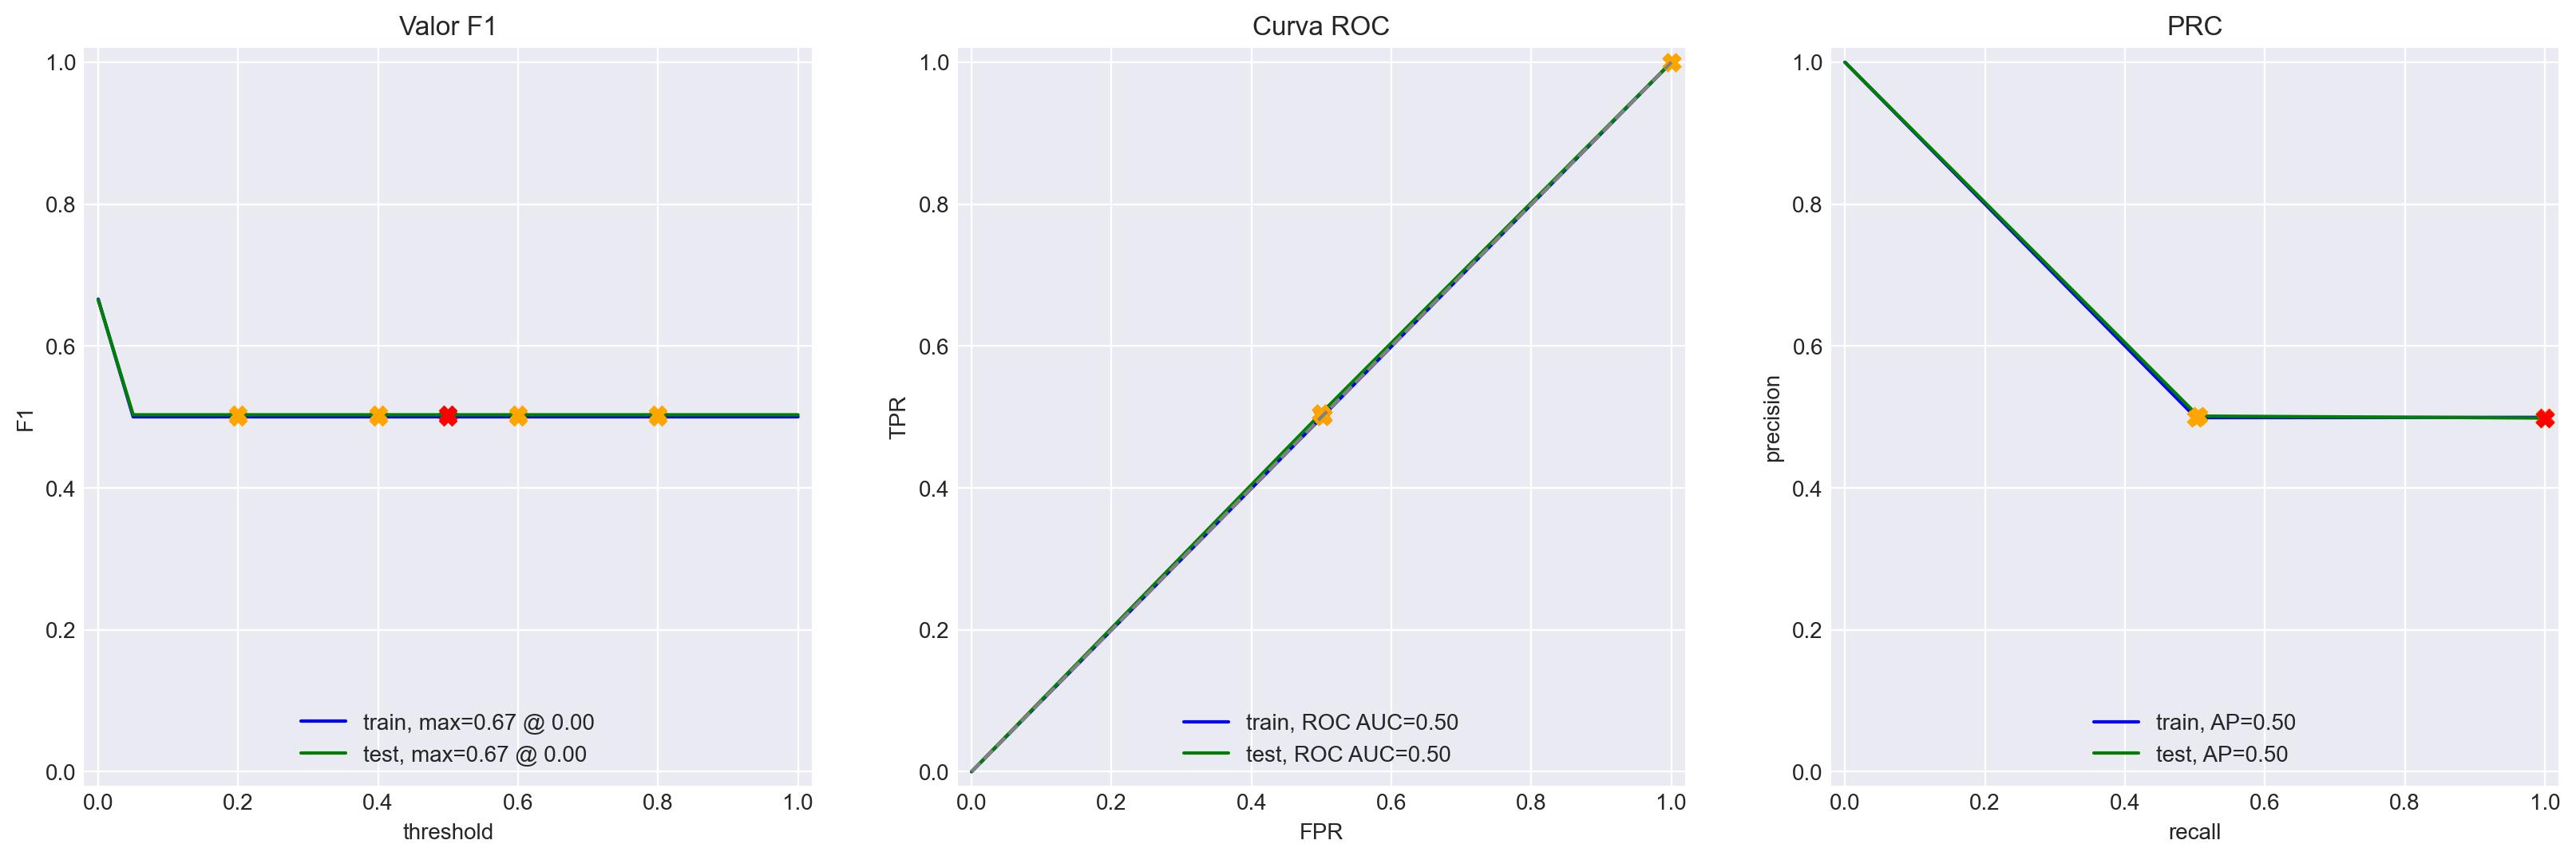

In [31]:
# instanciar o modelo Dummy
# 'stratified' garante que o "chute" respeite os ~50% de cada classe que você calculou
model_dummy = DummyClassifier(strategy='stratified', random_state=42)

# definição das features para os conjuntos de treinamento e teste
train_features = df_reviews_train['review_norm']
test_features = df_reviews_test['review_norm']

# treinar o modelo
model_dummy.fit(train_features, train_target)

# chamar a função de avaliação para o modelo Dummy
print('=' * 50)
print(f"📈 Resultados: Modelo 0 (Constante/Dummy)")
print('=' * 50)

res_dummy =evaluate_model(
    model_dummy, 
    train_features, 
    train_target, 
    test_features, 
    test_target, 
    model_name='Modelo 0: Constante/Dummy'
    )

# criação de uma lista global para armazenar os resumos dos modelos para apresentação final
resumo_modelos = []
# adicionar à lista global de resultados
resumo_modelos.append(res_dummy)

print(res_dummy)

`Análise da Performance do Modelo 0: Constante / Dummy (baseline)`
- As métricas de acurácia, APS e ROC AUC com resultado de 0.49, confirmando que o modelo trabalha "ao acaso", sem capacidade de distinção de resenhas positivas e negativas.
- F1-score o resultado foi 0.66 no limiar 0.0, este resultado não representa melhoria real da qualidade de classificação, visto ser um resultado devido a classificação de todas as instâncias como positivas no dataset balanceado.
- **Modelo Rejeitado:** o Modelo apresentou F1-score 0.67, não atende ao requesito do projeto (F1-score > 0.85).


### Modelo 1 - NLTK, TF-IDF e Regressão Linear

TF-IDF - Regressão Linear

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\galli\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


📈 Resultados: Modelo 1 (NLTK + TF-IDF + Regressão Linear)
                     train     test
Accuracy            1.0000  0.73148
F1                  1.0000  0.74948
APS                 1.0000  0.78741
ROC AUC             1.0000  0.80533
Inference Time (s)  0.0114  0.01066


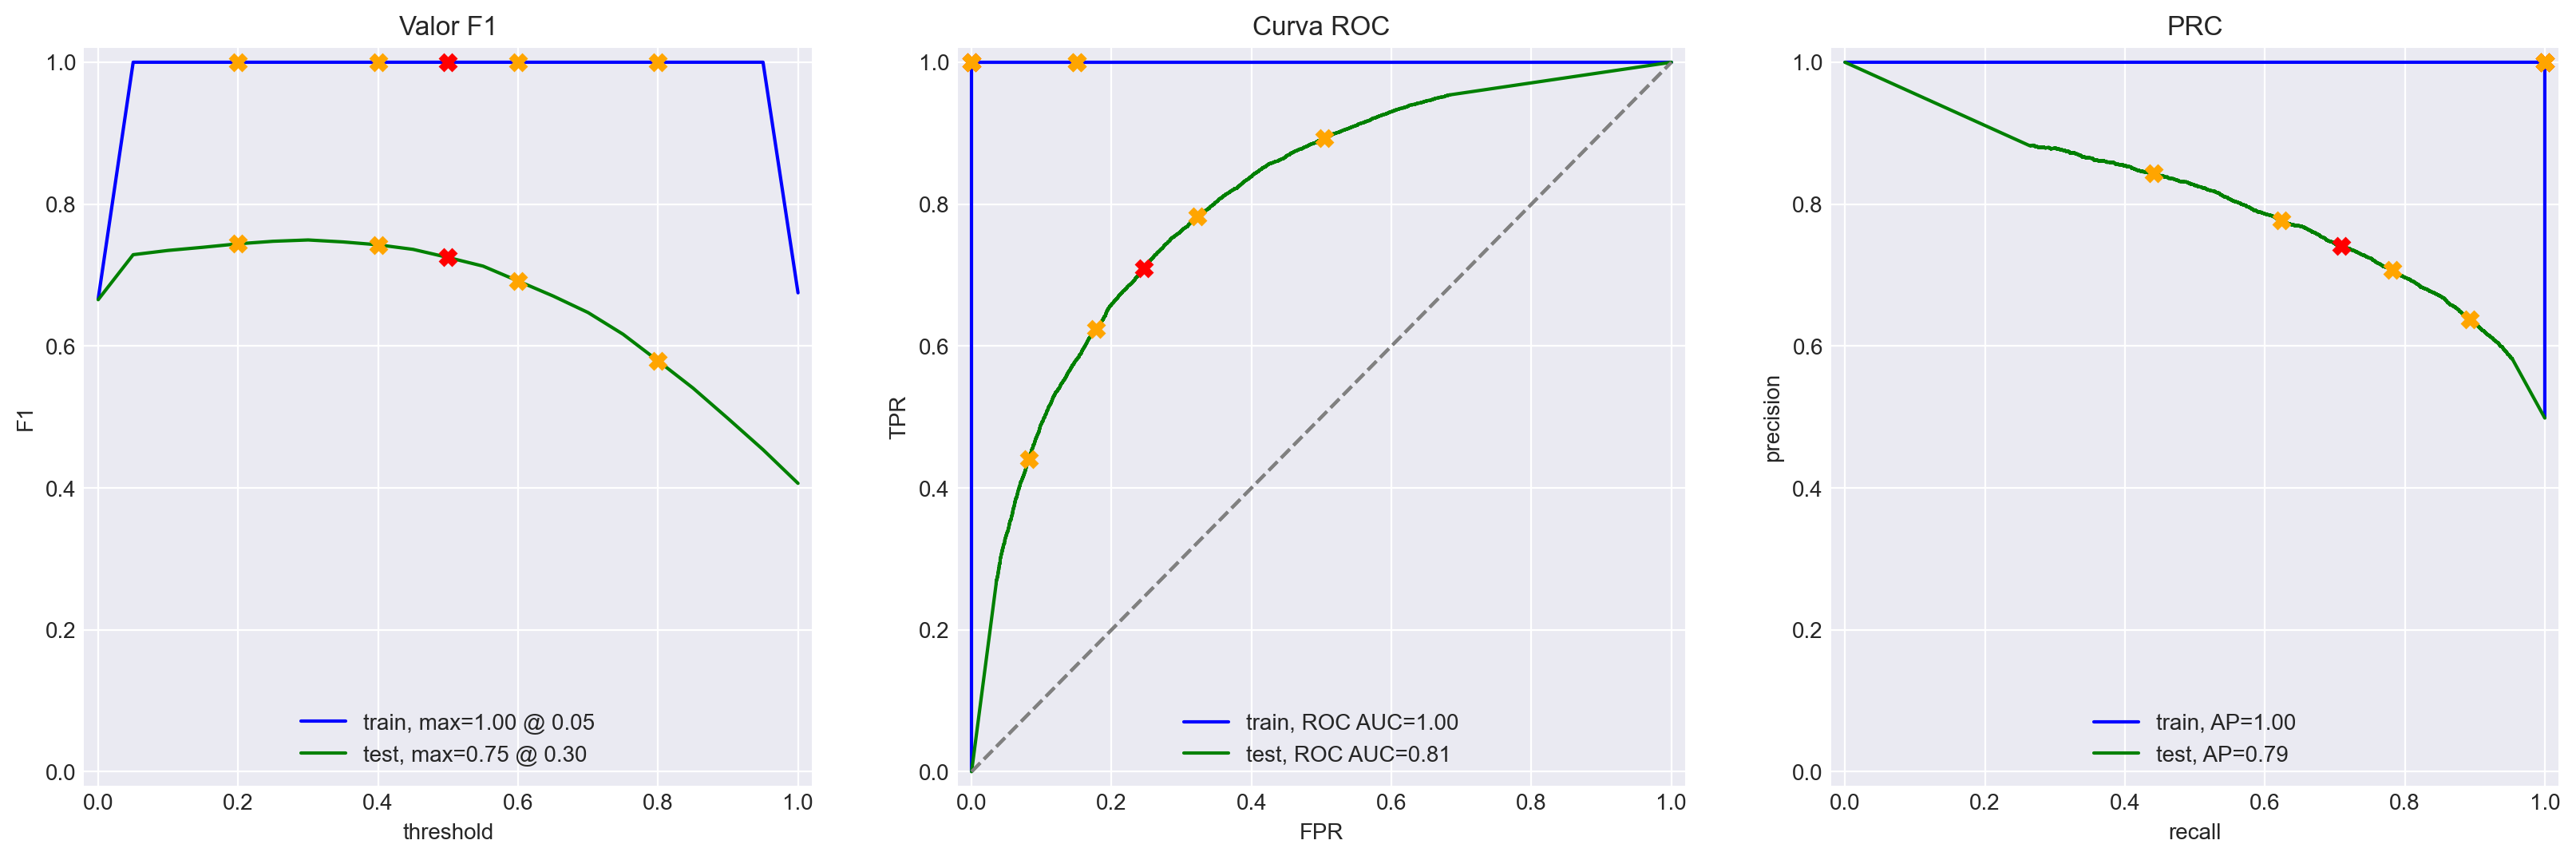

In [32]:
# instanciar o modelo TF-IDF
# baixando as stop words do NLTK para o idioma inglês
nltk.download('stopwords')
stop_words = list(set(nltk.corpus.stopwords.words('english')))

# instanciar o vetorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer(stop_words=stop_words)

# transformar o texto em números (features)
train_features_1 = tfidf_vectorizer.fit_transform(df_reviews_train['review_norm'])
test_features_1 = tfidf_vectorizer.transform(df_reviews_test['review_norm'])

# instanciar e treinar o modelo de regressão linear
model_linear = LinearRegression()
model_linear.fit(train_features_1, train_target)

# Regressão Linear não possui o método 'predict_proba' por padrão
# solução: simulação do componente de probabilidade em que guardamos a função original de predição numérica em uma variável
original_predict = model_linear.predict

# função para criar e definir o predict_proba
def predict_proba_linear(features):
    # usamos a original_predict para pegar os valores contínuos (ex: 0.8, 1.2, -0.2)
    preds = original_predict(features)
    # clipamos os valores para que fiquem entre 0 e 1, já que são probabilidades
    preds_clipped = np.clip(preds, 0, 1)
    # retorna um array 2D com uma coluna para cada classificação (0 e 1)
    return np.vstack([1 - preds_clipped, preds_clipped]).T

# atribuição da nova função ao modelo
model_linear.predict_proba = predict_proba_linear

# predict final para classificação (0 ou 1)
# se >= 0.5 classifica como positivo (1), caso contrário negativo (0)
model_linear.predict = lambda features: (model_linear.predict_proba(features)[:, 1] >= 0.5).astype(int)

# chamar a função de avaliação para o Linear Regression
print('=' * 70)
print(f"📈 Resultados: Modelo 1 (NLTK + TF-IDF + Regressão Linear)")
print('=' * 70)

res_linear = evaluate_model(
    model_linear, 
    train_features_1, 
    train_target, 
    test_features_1, 
    test_target, 
    model_name='Modelo 1: NLTK + TF-IDF + Regressão Linear'
)

#  adicionar à lista global de resultados
resumo_modelos.append(res_linear)

`Análise da Performance do Modelo 1: NLTK, TF-IDF e Regressão Linear`
- O Modelo de Regressão Linear preve números contínuos (regressão) e não classes (classificação), portanto, não possui nativamente o método .predict_proba(). A sua função evaluate_model exige o método para calcular as curvas ROC e F1, a função predict_proba_linear garante que a função de avaliação dos modelos funcione.
- Os resultados mostram overfitting severo, atingindo métricas perfeitas (1.0) no treino, mas falhando em manter a performance no teste (F1 = 0.75).
- Como Regressão Linear não tem mecanismos de regulação, no treino, consegue chegar tão perto do 0 ou do 1 que, ao arredondar, o modelo crava 100% de acerto. No teste, as predições provavelmente estão saindo do intervalo $[0, 1]$ (ex: prevendo 1.5 ou -0.4), o que distorce completamente a curva ROC e o F1.
- **Modelo Rejeitado:** o Modelo é rejeitado para este projeto devido à alta variância e falta de robustez frente a novos dados. F1-score: 0.75.

### Modelo 2 - NLTK, TF-IDF e Regressão Logística

TF-IDF - Regressão Logística

📈 Resultados: Modelo 2 (NLTK + TF-IDF + Regressão Logística)
                      train     test
Accuracy            0.93759  0.88234
F1                  0.93802  0.88404
APS                 0.98382  0.94977
ROC AUC             0.98336  0.95218
Inference Time (s)  0.01008  0.01014
{'Model': 'Modelo 2: NLTK + TF-IDF + Regressão Logística', 'Accuracy': np.float64(0.88234), 'F1': np.float64(0.88404), 'APS': np.float64(0.94977), 'ROC AUC': np.float64(0.95218), 'Time (s)': 0.010141134262084961}


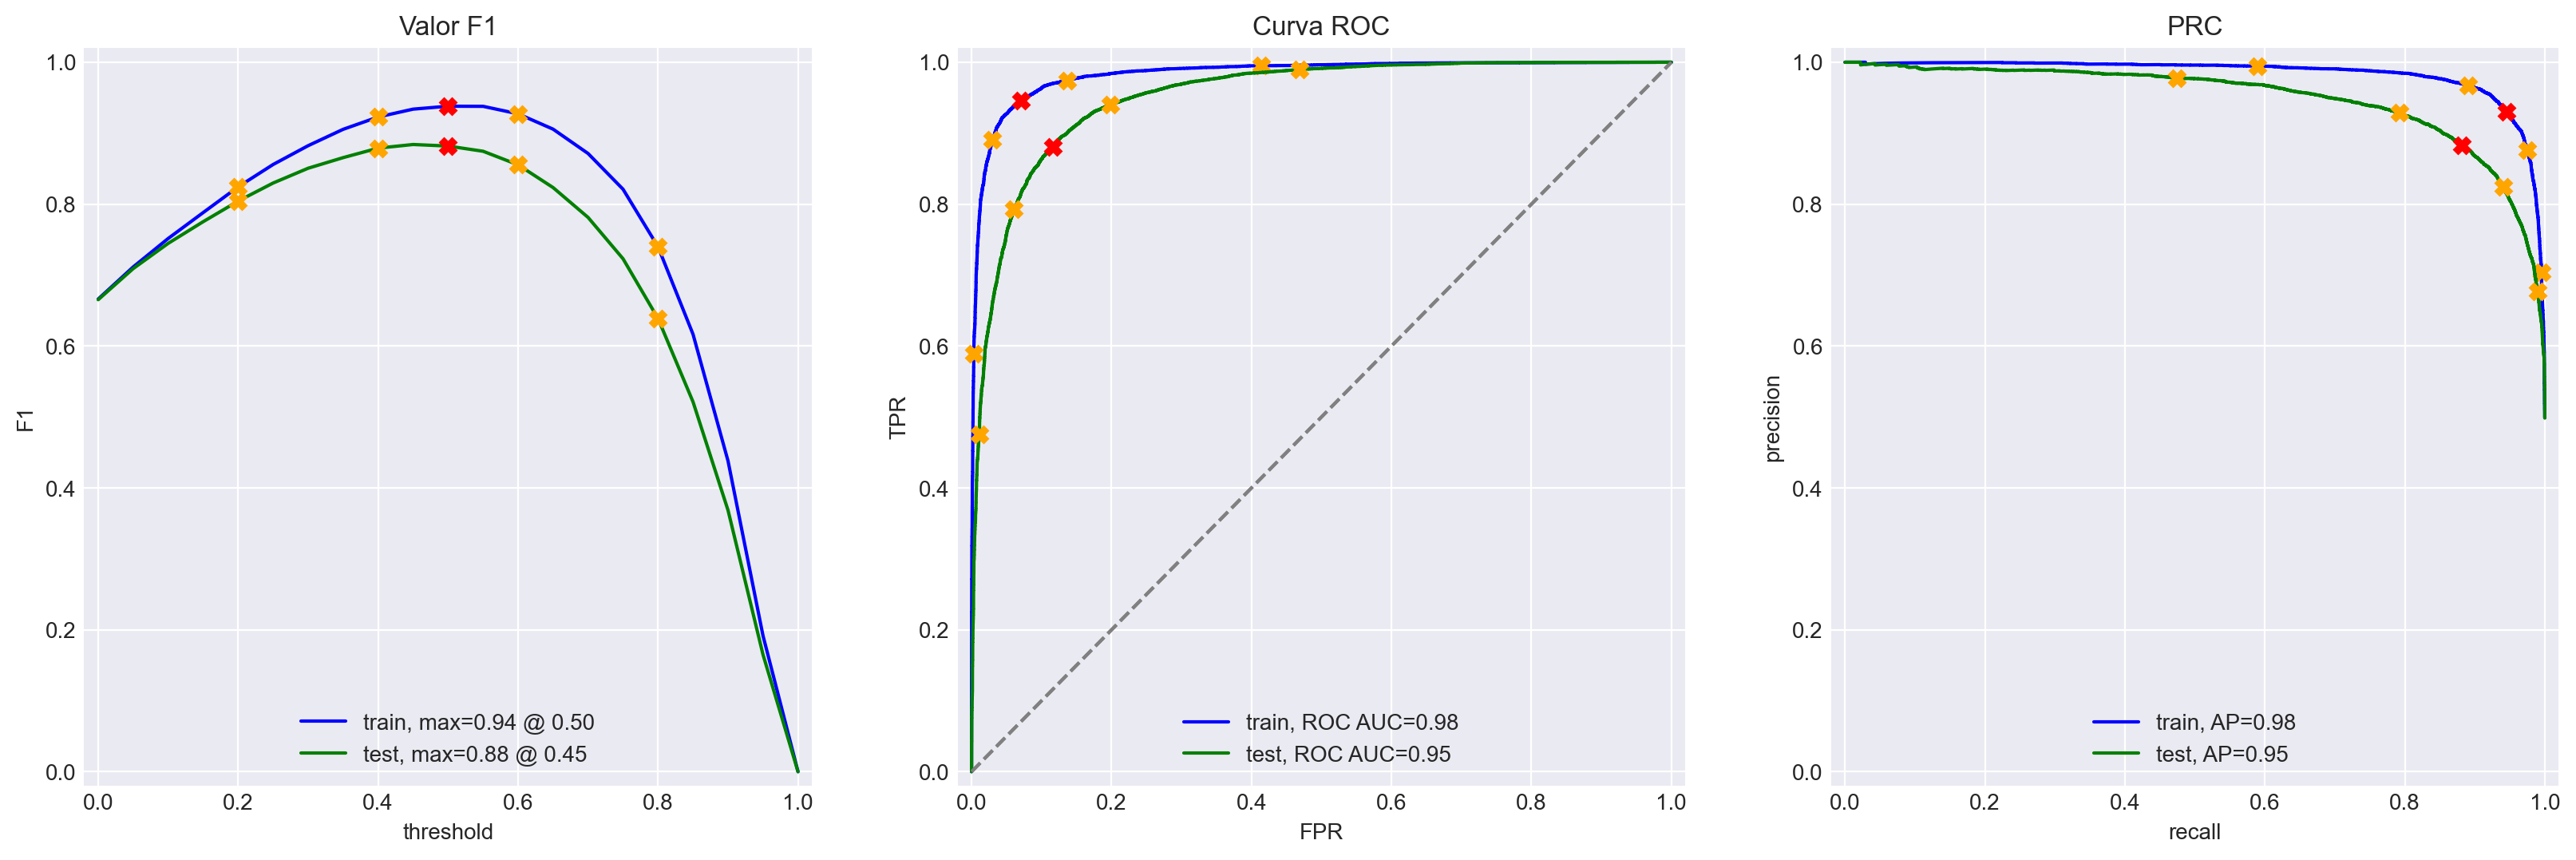

In [33]:
# instanciar o vetorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer(stop_words=stop_words)

# transformar o texto em números (features)
train_features_2 = tfidf_vectorizer.fit_transform(df_reviews_train['review_norm'])
test_features_2 = tfidf_vectorizer.transform(df_reviews_test['review_norm'])

# instanciar o modelo de regressão logística
model_2 = LogisticRegression(random_state=42)

# treinar o modelo
model_2.fit(train_features_2, train_target)

# chamar a função de avaliação para o modelo de regressão logística
print('=' * 70)
print(f"📈 Resultados: Modelo 2 (NLTK + TF-IDF + Regressão Logística)")
print('=' * 70)

res_logistic = evaluate_model(
    model_2, 
    train_features_2, 
    train_target, 
    test_features_2, 
    test_target, 
    model_name='Modelo 2: NLTK + TF-IDF + Regressão Logística'
    )

# adicionar à lista global de resultados
resumo_modelos.append(res_logistic)

print(res_logistic)

`Análise de Performance do Modelo 2: NLTK + TF-IDF + Regressão Logística`
- Optou-se em utilizar Regressão Logística, pois é mais adequado para problemas de classificação binária de sentimentos, pois retorna a probabilidade de pertercer ou não a determinada categoria.
- Superação do Baseline: o modelo demonstrou um aprendizado real, saindo de um ROC AUC de 0.50 (acaso) para 0.95, evidenciando que a vetorização TF-IDF com Stop Words foi eficaz em extrair semântica das resenhas.
- Overfitting: embora exista um leve distanciamento entre as métricas de treino (0.94) e teste (0.88), o modelo mantém uma alta capacidade de generalização. O valor de APS (0.95) confirma que a precisão média é consistente em diferentes níveis de recall.
- **Modelo Não Rejeitado:** diferente da Regressão Linear que não lida bem com a esparsidade do TF-IDF em problemas de classificação, a Regressão Logística atingiu F1-score 0.88 no conjunto de teste, superando a meta estabelecida de 0.85.

### Modelo 3 - SpaCy, TF-IDF e Regressão Logística

In [34]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

# função para processamento em lote usando spaCy para lematização para ganho de performance
def text_preprocessing_3(texts):
    clean_texts = []
    for doc in tqdm(nlp.pipe(texts, batch_size=500, n_process=-1)):
        tokens = [token.lemma_ for token in doc]
        clean_texts.append(' '.join(tokens))
    return clean_texts

# aplicando nos dataframes de treinamento e teste, criando novas colunas 'review_spacy' com os textos lematizados
print("--- Iniciando Lematização com SpaCy... ---")
df_reviews_train['review_spacy'] = text_preprocessing_3(df_reviews_train['review_norm'])
df_reviews_test['review_spacy'] = text_preprocessing_3(df_reviews_test['review_norm'])

--- Iniciando Lematização com SpaCy... ---


23796it [01:58, 200.20it/s]
23533it [01:29, 262.44it/s] 


📈 Resultados: Modelo 3 (spaCy + TF-IDF + Regressão Logística)
                      train     test
Accuracy            0.93024  0.87868
F1                  0.93083  0.87880
APS                 0.97994  0.94654
ROC AUC             0.97947  0.94922
Inference Time (s)  0.00605  0.00734


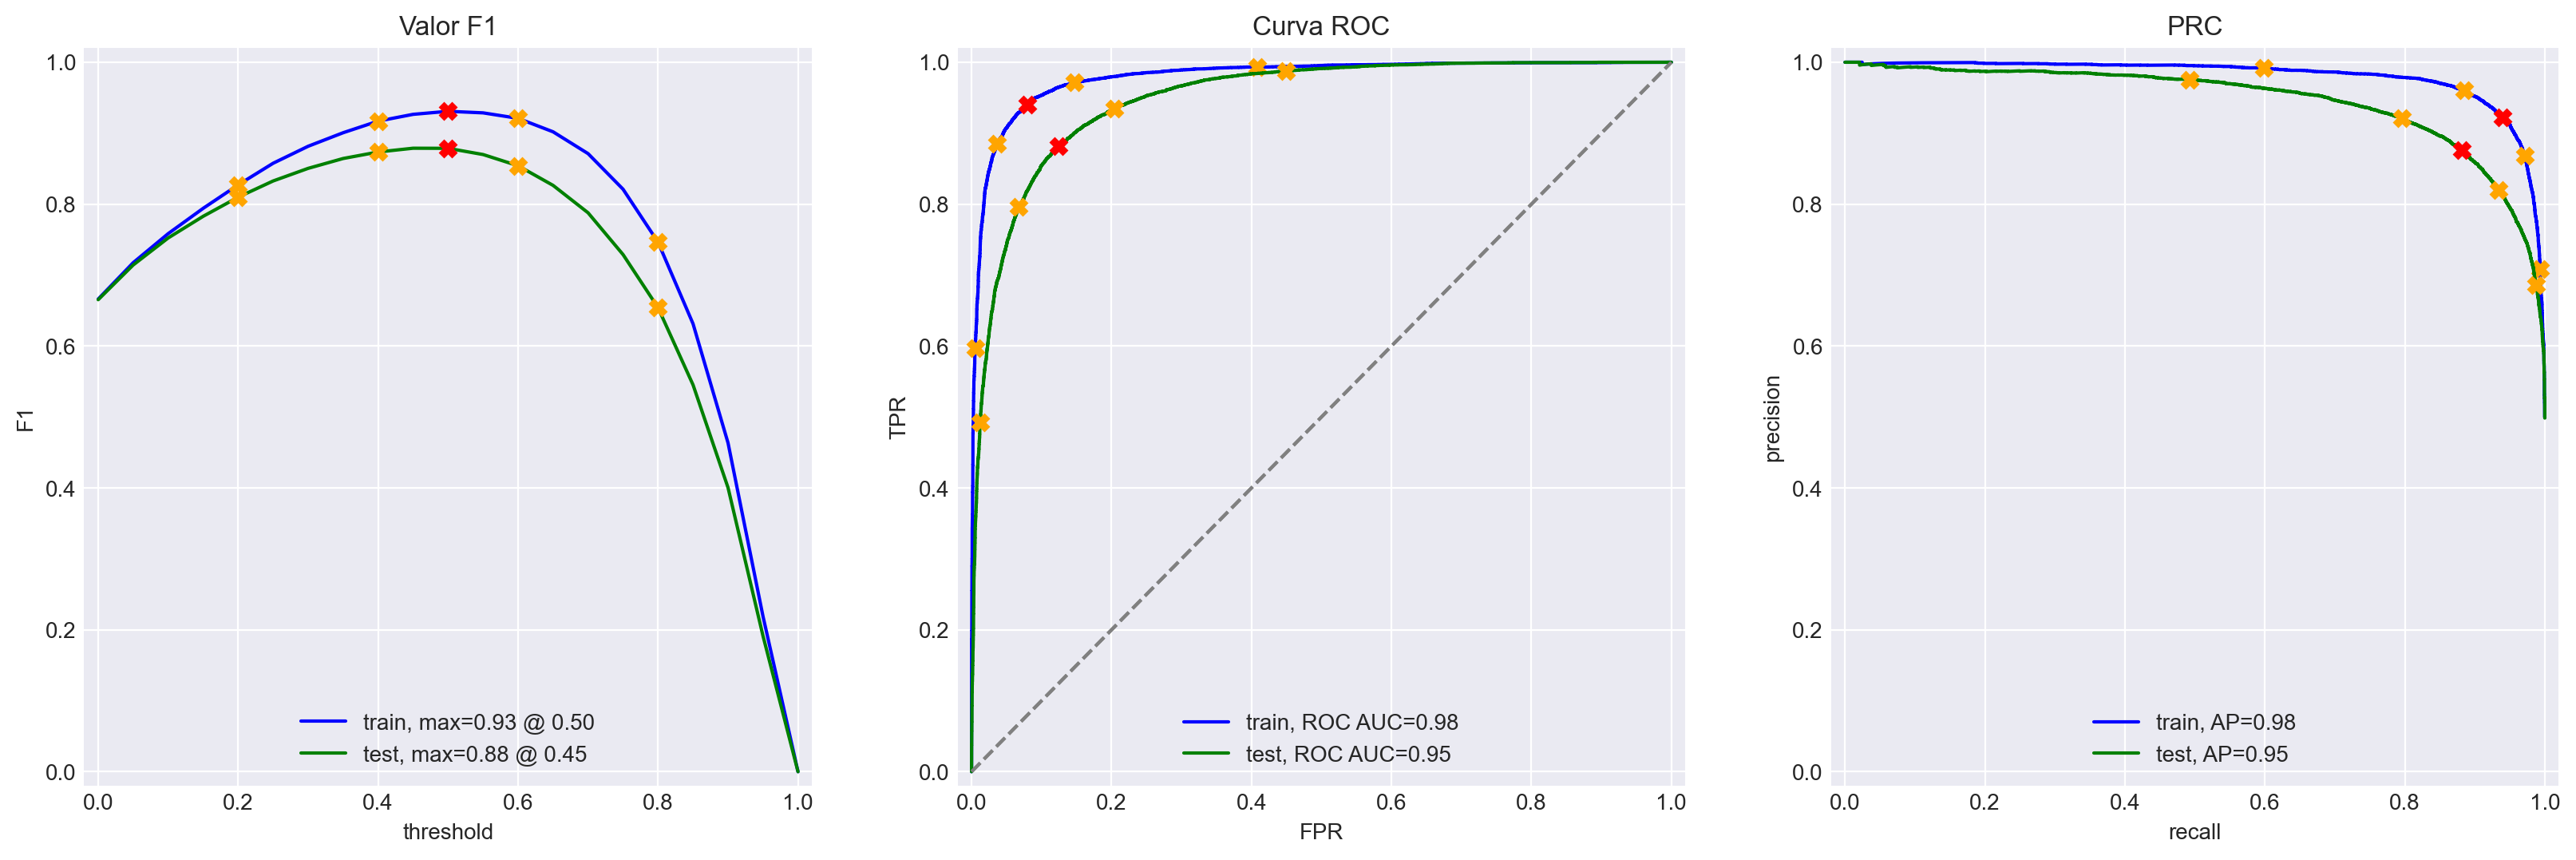

In [35]:
# vetorização TF-IDF
tfidf_3 = TfidfVectorizer(stop_words=stop_words)

# transformação dos textos lematizados em números (features)
train_features_3 = tfidf_3.fit_transform(df_reviews_train['review_spacy'])
test_features_3 = tfidf_3.transform(df_reviews_test['review_spacy'])

# instanciar e treinar o modelo de regressão logística
model_3 = LogisticRegression(random_state=42, max_iter=1000)
model_3.fit(train_features_3, train_target)

# chamar a função de avaliação para o modelo de regressão logística
print('=' * 70)
print(f"📈 Resultados: Modelo 3 (spaCy + TF-IDF + Regressão Logística)")
print('=' * 70)

res_spacy = evaluate_model(
    model_3, 
    train_features_3, 
    train_target, 
    test_features_3, 
    test_target, 
    model_name='Modelo 3: SpaCy + TF-IDF + Regressão Logística'
)

# adicionar à lista global de resultados
resumo_modelos.append(res_spacy)

`Análise de Performance do Modelo 3: spaCy + TF-IDF + Regressão Logística`
- Embora o spaCy utilize técnicas de NLP mais avançadas, não trouxe um ganho de performance significativo em relação ao NLTK. 
- **Modelo Não Rejeitado**: o Modelo 3 atende ao requesito F1 > 0.85. Porém, visto que o spaCy é computacionalmente mais caro e lento para processar (etapa de lematização), o NLTK (Modelo 2) é a escolha mais eficiente para produção, entregando a mesma acurácia com menor custo de processamento (F1-score > 0.85).

### Modelo 4 - SpaCy, TF-IDF e LGBMClassifier

[LightGBM] [Info] Number of positive: 11884, number of negative: 11912
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.216785 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 455716
[LightGBM] [Info] Number of data points in the train set: 23796, number of used features: 9351
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499412 -> initscore=-0.002353
[LightGBM] [Info] Start training from score -0.002353
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

c:\Users\galli\Projetos\T10\14_film_sentiment_classifier\film-sentiment-classifier\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\galli\Projetos\T10\14_film_sentiment_classifier\film-sentiment-classifier\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\galli\Projetos\T10\14_film_sentiment_classifier\film-sentiment-classifier\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\galli\Projetos\T10\14_film_sentiment_classifier\film-sentiment-classifier\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with fea

                      train     test
Accuracy            0.94402  0.85323
F1                  0.94640  0.85634
APS                 0.98856  0.93203
ROC AUC             0.98869  0.93411
Inference Time (s)  0.37458  0.23878


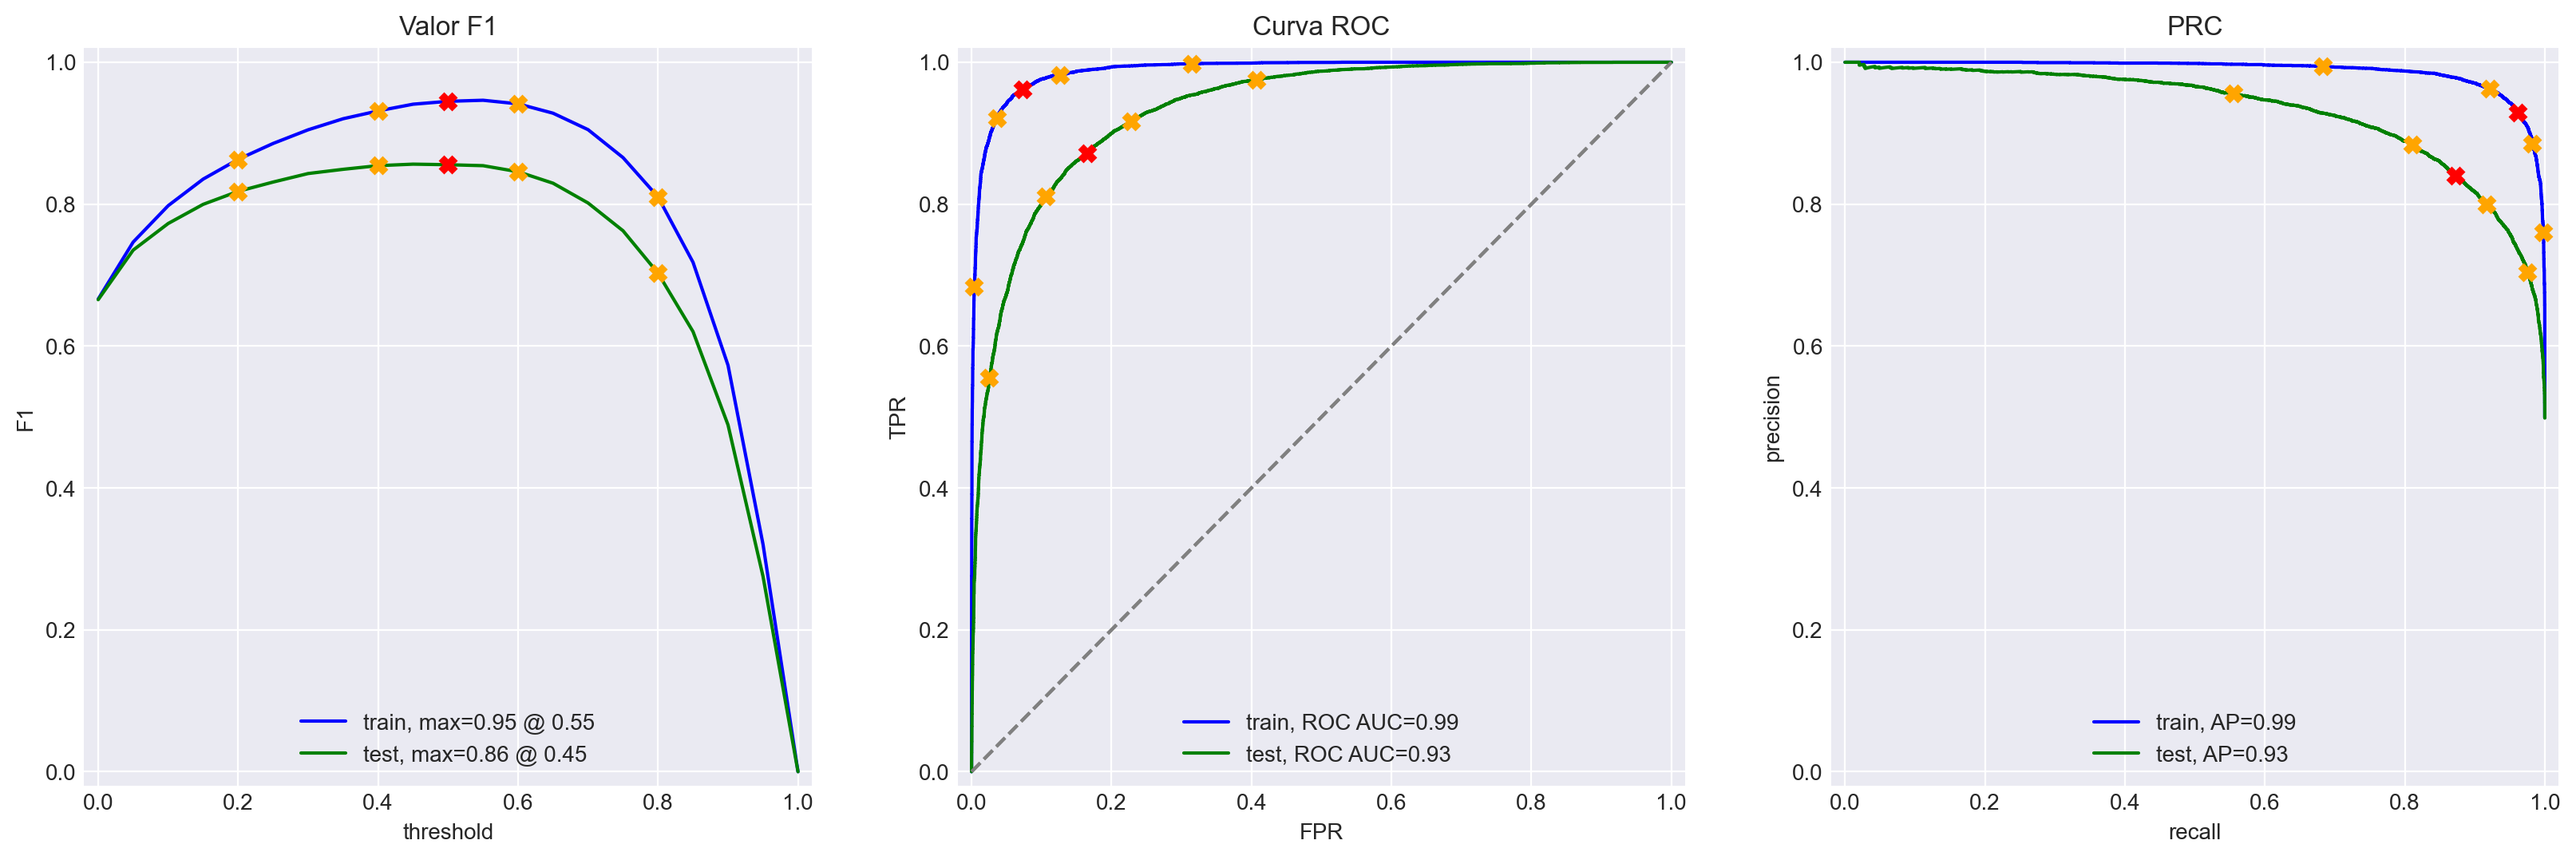

In [36]:
# instanciar o modelo LightGBM
# definição de hiperparâmetros para evitar overfitting
model_4 = LGBMClassifier(
    n_estimators=500,         # número de árvores
    learning_rate=0.05,       # velocidade de aprendizado
    num_leaves=31,            # número máximo de folhas por árvore
    random_state=42,          # garantia de reprodutibilidade
    importance_type='gain',   # tipo de importância das features
    max_depth=7,              # profundidade máxima das árvores
    n_jobs=-1                 # usar todos os núcleos do processador
)

# treinar modelo LightGBM com os dados lematizados e vetorizados
model_4.fit(train_features_3, train_target)

# chamar a função de avaliação para o modelo LightGBM
print('=' * 70)
print(f"📈 Resultados: Modelo 4 (spaCy + TF-IDF + LightGBM)")
print('=' * 70)

res_lgbm = evaluate_model(
    model_4, 
    train_features_3, 
    train_target, 
    test_features_3, 
    test_target, 
    model_name='Modelo 4: SpaCy + TF-IDF + LGBM'
)

# adicionar à lista global de resultados
resumo_modelos.append(res_lgbm)

`Análise de Performance do Modelo 4: spaCy + TF-IDF + LightGBM`
- O Modelo 4 LGBM apresentou F1-score 0.85, um pouco abaixo dos modelos 2 e 3. Assim como, apresentou inference time superior aos modelos treinados previamente.
- **Modelo Não Rejeitado**: apesar de o Modelo LGBM ser mais moderno que os anteriores, o Modelo 2 (Regressão Logística com pré-processamento NLTK) continua sendo a recomendação ideal para o cliente, especialmente por ser mais leve e rápida para processar as resenhas, e ter atingido o maior F1-score absoluto (0.88).

###  Modelo 5 - BERT

In [37]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5711.65it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [38]:
import torch

def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None, disable_progress_bar=False):
    
    ids_list = []
    attention_mask_list = []

    # tokenização: transformar texto em IDs e Máscaras
    for text in texts:
        # o tokenizer faz o truncamento e o preenchimento (padding) automaticamente
        encoded = tokenizer(
            text,
            add_special_tokens=True,    # adiciona [CLS] e [SEP]
            max_length=max_length,      # limite de 512 tokens
            padding='max_length',       # preenche com zeros se for menor
            truncation=True,            # corta se for maior
            return_attention_mask=True, # cria a máscara de zeros e uns
            return_tensors=None         # retorna listas simples de Python
        )
        ids_list.append(encoded['input_ids'])
        attention_mask_list.append(encoded['attention_mask'])

    # mover o modelo para o dispositivo configurado    
    model.to(device)
    if not disable_progress_bar:
        print(f'Usando o dispositivo {device}.')
    
    # receber as incorporações (embeddings) em lotes
    embeddings = []

    for i in tqdm(range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar):
        
        # criar os lotes de IDs e máscaras para o lote atual
        ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
        attention_mask_batch = torch.LongTensor(attention_mask_list[batch_size*i:batch_size*(i+1)]).to(device)
    
        with torch.no_grad():            
            model.eval()
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch) 
        # extração apenas [CLS] índice 0, que representa o sentimento da frase completa
        embeddings.append(batch_embeddings[0][:,0,:].detach().cpu().numpy())
        
    return np.concatenate(embeddings)

--- Extraindo Embeddings do BERT (Isso pode levar alguns minutos)... ---
Usando o dispositivo cpu.


100%|██████████| 2/2 [00:38<00:00, 19.30s/it]


Usando o dispositivo cpu.


100%|██████████| 2/2 [00:41<00:00, 20.71s/it]


📈 Resultados do Modelo 5: BERT + Regressão Logística
                      train     test
Accuracy            1.00000  0.81500
F1                  1.00000  0.86869
APS                 1.00000  0.94010
ROC AUC             1.00000  0.92523
Inference Time (s)  0.00107  0.00090


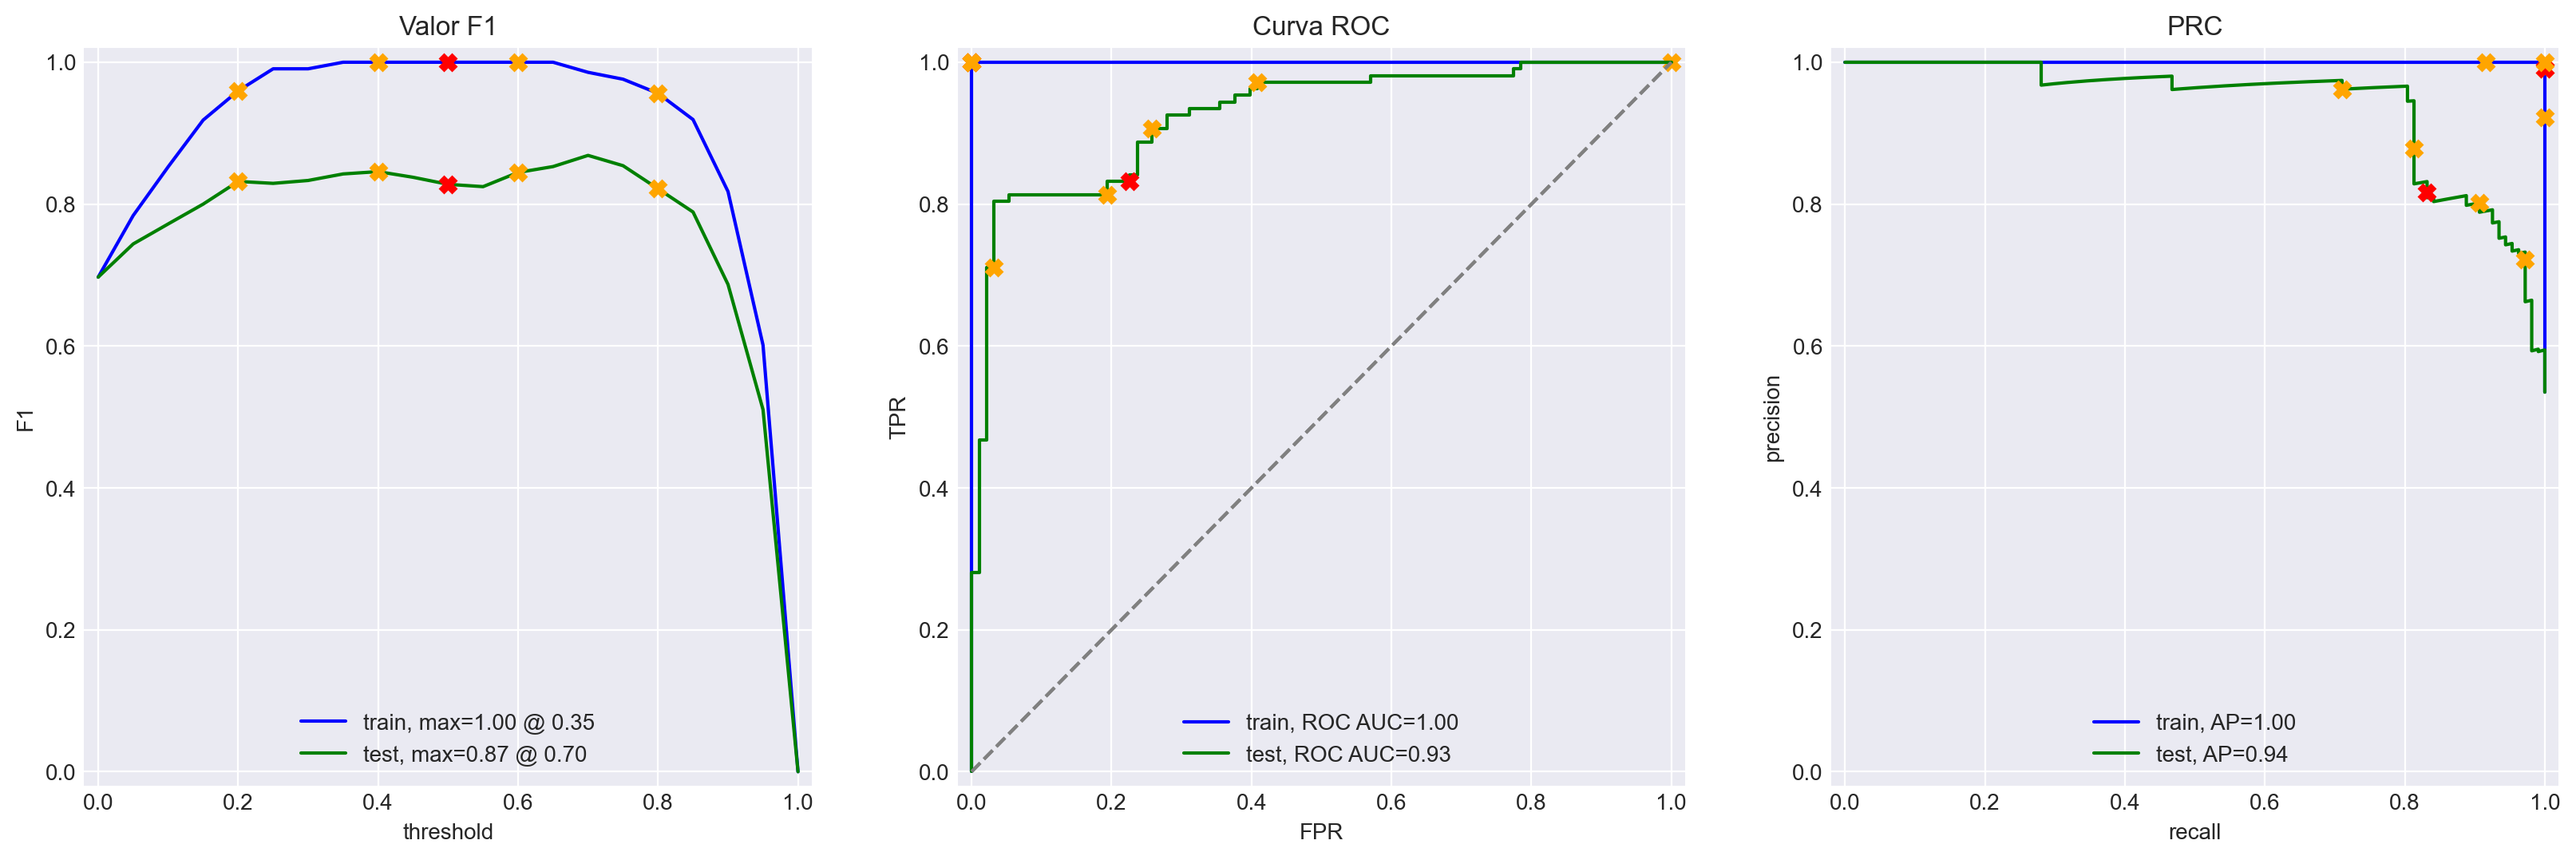

In [39]:
# criar amostras pequenas (200 de treino, 200 de teste)
df_bert_train = df_reviews_train.sample(200, random_state=42)
df_bert_test = df_reviews_test.sample(200, random_state=42)

# configurar o dispositivo para processamento (GPU se disponível, caso contrário CPU)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# gerar os embeddings do BERT para os conjuntos de treinamento e teste
print("--- Extraindo Embeddings do BERT (Isso pode levar alguns minutos)... ---")
train_features_bert = BERT_text_to_embeddings(df_bert_train['review_norm'], force_device=device)
test_features_bert = BERT_text_to_embeddings(df_bert_test['review_norm'], force_device=device)

# backup de segurança para evitar perda de tempo em futuras execuções, salvando os embeddings em um arquivo compactado
np.savez_compressed('bert_features.npz', 
                    train=train_features_bert, 
                    test=test_features_bert,
                    train_target=df_bert_train['pos'],
                    test_target=df_bert_test['pos'])

# treinar o modelo de regressão logística com os embeddings do BERT
model_bert = LogisticRegression(random_state=42, max_iter=1000)
model_bert.fit(train_features_bert, df_bert_train['pos'])

# 4. Avaliando
print('=' * 55)
print(f"📈 Resultados do Modelo 5: BERT + Regressão Logística")
print('=' * 55)

res_bert = evaluate_model(
    model_bert, 
    train_features_bert, df_bert_train['pos'], 
    test_features_bert, df_bert_test['pos'], 
    model_name='Modelo 5: BERT + Regressão Logística'
)

resumo_modelos.append(res_bert)

`Análise de Performance do Modelo 5: BERT + Regressão Logística`
- BERT apresentou overfitting extremo, com os dados de treinamento cravados em 1.0 (Acurácia, F1, APS e ROC AUC) para um modelo de linguagem natural não é o ideal e nem o esperado para um modelo que generaliza bem. O modelo mostrou-se mais lento para processar (etapa de extração de Embeddings do BERT)
- **Modelo Não Rejeitado**: apesar de o Modelo BERT atender ao requesito (F1-score > 0.85) e seja o recomendado para problemas de classificação de resenhas, o Modelo 2 (NLTK + TF-IDF + Regressão Logística) continua sendo a melhor escolha para este projeto. Visto que, o Modelo 2 atingiu 0.88 de F1 de forma mais estável, é mais leve para o servidor e não exige hardware caro (GPU) para processar novas resenhas.

## Minhas Resenhas

In [40]:
# resenhas experimentais para testar os modelos

my_reviews = pd.DataFrame([
    'I simply did not like it, it is not my type of movie.',
    'Well, I got bored and fell asleep in the middle of the movie.',
    'I was really fascinated with the movie.',    
    'The actors looked too old and disinterested, and yet they were paid to be in the movie. What a shameless money grab.',
    'I did not expect the new version to be so good! The writers really cared about the original material.',
    'The movie has its pros and cons, but I feel that overall it is a decent movie. I can imagine myself watching it again.',
    'What a rotten attempt at comedy. Not a single joke lands, everyone acts in an annoying and loud way, not even children will like this!',
    'Releasing it on Netflix was a brave move and I really appreciate being able to watch episode after episode of this exciting and intelligent new drama.'
], columns=['review'])


my_reviews['review_norm'] = (my_reviews['review']
                             .str.lower()
                             .replace(r'[^a-zA-Z\s]', ' ', regex=True)
                             .replace(r'\s+', ' ', regex=True)
                             .str.strip()
)

display(my_reviews)

,review,review_norm
0,"I simply did not like it, it is not my type of...",i simply did not like it it is not my type of ...
1,"Well, I got bored and fell asleep in the middl...",well i got bored and fell asleep in the middle...
2,I was really fascinated with the movie.,i was really fascinated with the movie
3,"The actors looked too old and disinterested, a...",the actors looked too old and disinterested an...
4,I did not expect the new version to be so good...,i did not expect the new version to be so good...
5,"The movie has its pros and cons, but I feel th...",the movie has its pros and cons but i feel tha...
6,What a rotten attempt at comedy. Not a single ...,what a rotten attempt at comedy not a single j...
7,Releasing it on Netflix was a brave move and I...,releasing it on netflix was a brave move and i...


### Modelo 2

In [48]:
texts = my_reviews['review_norm']

# iniciando o cronômetro
start_time_2 = time.time()

# Modelo 2 (NLTK + TF-IDF + Regressão Logística)
my_reviews_pred_prob = model_2.predict_proba(tfidf_vectorizer.transform(texts))[:, 1]

# parando o cronômetro
end_time_2 = time.time()
inference_time_2 = end_time_2 - start_time_2

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

print()
print(f'Tempo de inferência Modelo 2: {inference_time_2:.4f} segundos')

0.27:  i simply did not like it it is not my type of movie
0.18:  well i got bored and fell asleep in the middle of the movie
0.53:  i was really fascinated with the movie
0.11:  the actors looked too old and disinterested and yet they were paid to be in the movie what a shamele
0.22:  i did not expect the new version to be so good the writers really cared about the original material
0.42:  the movie has its pros and cons but i feel that overall it is a decent movie i can imagine myself wa
0.04:  what a rotten attempt at comedy not a single joke lands everyone acts in an annoying and loud way no
0.87:  releasing it on netflix was a brave move and i really appreciate being able to watch episode after e

Tempo de inferência Modelo 2: 0.0011 segundos


### Modelo 3

In [49]:
texts = my_reviews['review_norm']

# iniciando o cronômetro
start_time_3 = time.time()

# Modelo 3 (spaCy + TF-IDF + Regressão Logística)#
my_reviews_pred_prob = model_3.predict_proba(tfidf_3.transform(texts.apply(lambda x: text_preprocessing_3(x)).str.join('')))[:, 1]

# parando o cronômetro
end_time_3 = time.time()
inference_time_3 = end_time_3 - start_time_3

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

print()
print(f'Tempo de inferência Modelo 3: {inference_time_3:.2f} segundos')

51it [00:35,  1.42it/s]
59it [00:36,  1.63it/s]
38it [00:36,  1.05it/s]
113it [00:36,  3.13it/s]
99it [00:35,  2.77it/s]
115it [00:35,  3.21it/s]
130it [00:35,  3.62it/s]
149it [00:36,  4.07it/s]

0.31:  i simply did not like it it is not my type of movie
0.24:  well i got bored and fell asleep in the middle of the movie
0.47:  i was really fascinated with the movie
0.33:  the actors looked too old and disinterested and yet they were paid to be in the movie what a shamele
0.43:  i did not expect the new version to be so good the writers really cared about the original material
0.40:  the movie has its pros and cons but i feel that overall it is a decent movie i can imagine myself wa
0.07:  what a rotten attempt at comedy not a single joke lands everyone acts in an annoying and loud way no
0.93:  releasing it on netflix was a brave move and i really appreciate being able to watch episode after e

Tempo de inferência Modelo 3: 288.60 segundos


### Modelo 4

In [50]:
texts = my_reviews['review_norm']

# iniciando o cronômetro
start_time_4 = time.time()

# Modelo 4 (spaCy + TF-IDF + LightGBM)
tfidf_vectorizer_4 = tfidf_3

my_reviews_pred_prob = model_4.predict_proba(tfidf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_3(x)).str.join('')))[:, 1]

# parando o cronômetro
end_time_4 = time.time()
inference_time_4 = end_time_4 - start_time_4

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

print()
print(f'Tempo de inferência Modelo 4: {inference_time_4:.2f} segundos')

51it [00:36,  1.40it/s]
59it [00:36,  1.61it/s]
38it [00:36,  1.03it/s]
113it [00:35,  3.15it/s]
99it [00:35,  2.77it/s]
115it [00:35,  3.22it/s]
130it [00:36,  3.59it/s]
149it [00:35,  4.20it/s]

0.60:  i simply did not like it it is not my type of movie
0.47:  well i got bored and fell asleep in the middle of the movie
0.60:  i was really fascinated with the movie
0.49:  the actors looked too old and disinterested and yet they were paid to be in the movie what a shamele
0.67:  i did not expect the new version to be so good the writers really cared about the original material
0.62:  the movie has its pros and cons but i feel that overall it is a decent movie i can imagine myself wa
0.36:  what a rotten attempt at comedy not a single joke lands everyone acts in an annoying and loud way no
0.73:  releasing it on netflix was a brave move and i really appreciate being able to watch episode after e

Tempo de inferência Modelo 4: 288.97 segundos



c:\Users\galli\Projetos\T10\14_film_sentiment_classifier\film-sentiment-classifier\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Modelo 5

In [51]:
texts = my_reviews['review_norm']

# iniciando o cronômetro
start_time_5 = time.time()

my_reviews_features_5 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

my_reviews_pred_prob = model_bert.predict_proba(my_reviews_features_5)[:, 1]

# parando o cronômetro
end_time_5 = time.time()
inference_time_5 = end_time_5 - start_time_5

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

print()
print(f'Tempo de inferência Modelo 5: {inference_time_5:.2f} segundos')

0.05:  i simply did not like it it is not my type of movie
0.05:  well i got bored and fell asleep in the middle of the movie
0.92:  i was really fascinated with the movie
0.05:  the actors looked too old and disinterested and yet they were paid to be in the movie what a shamele
0.40:  i did not expect the new version to be so good the writers really cared about the original material
0.93:  the movie has its pros and cons but i feel that overall it is a decent movie i can imagine myself wa
0.06:  what a rotten attempt at comedy not a single joke lands everyone acts in an annoying and loud way no
0.97:  releasing it on netflix was a brave move and i really appreciate being able to watch episode after e

Tempo de inferência Modelo 5: 1.81 segundos


## Conclusões

In [54]:
# ----- resumo executivo final: comparação dos modelos -----

# criar o dataframe consolidado
df_comparativo_final = pd.DataFrame(resumo_modelos)
# formatar para a apresentação executiva
display(df_comparativo_final.sort_values(by='F1', ascending=False))

,Model,Accuracy,F1,APS,ROC AUC,Time (s)
2,Modelo 2: NLTK + TF-IDF + Regressão Logística,0.88234,0.88404,0.94977,0.95218,0.010141
3,Modelo 3: SpaCy + TF-IDF + Regressão Logística,0.87868,0.87880,0.94654,0.94922,0.007339
5,Modelo 5: BERT + Regressão Logística,0.81500,0.86869,0.94010,0.92523,0.000899
4,Modelo 4: SpaCy + TF-IDF + LGBM,0.85323,0.85634,0.93203,0.93411,0.238779
1,Modelo 1: NLTK + TF-IDF + Regressão Linear,0.73148,0.74948,0.78741,0.80533,0.010664
0,Modelo 0: Constante/Dummy,0.50283,0.66529,0.49987,0.50283,0.004760


In [62]:
# ----- resumo executivo final do tempo de treinamento e inferência: comparação dos modelos -----

print('=' * 50)
print("Resumo Executivo: Tempo de Inferência dos Modelos")
print('=' * 50)
print(f"Modelo 2: Tempo de Inferência: {inference_time_2:.4f} segundos")
print(f"Modelo 3: Tempo de Inferência: {inference_time_3:.4f} segundos")
print(f"Modelo 4: Tempo de Inferência: {inference_time_4:.4f} segundos")
print(f"Modelo 5: Tempo de Inferência: {inference_time_5:.4f} segundos")

Resumo Executivo: Tempo de Inferência dos Modelos
Modelo 2: Tempo de Inferência: 0.0011 segundos
Modelo 3: Tempo de Inferência: 288.6017 segundos
Modelo 4: Tempo de Inferência: 288.9696 segundos
Modelo 5: Tempo de Inferência: 1.8071 segundos


**Análise: Métrica vs Performance**

`Métrica Estatísticas (F1-Score)`
- Analisando exclusivamente o conjunto de teste fixo, os Modelos 2 e 3 atingiram o maior F1-score (0.88), superando a meta estabelecida de 0.85.
- Entre os Modelos 2 e 3, o Modelo 2 (NLTK) apresentou menor latência (mais rápido) que o Modelo 3 (spaCy), devido ao processamento mais leve de strings.
- Portanto, analisando exclusivamente a métrica F1-score, o Modelo 2 seria o escolhido.

`Performace em Dados Externo (Capacidade de Generalização)`
- O Modelo 5 BERT, apresentou F1-score ~ 0.87 (ligeiramente abaixo dos primeiros colocados), mas demonstrou superioridade na capacidade de resposta para novas palavras e generalização.
- BERT performou melhor ao apresentar predições mais polarizadas e decisões nítidas (ex: 0.05 para negativas e 0.97 para positivas), enquanto os modelos lineares mostraram-se mais indecisos.
- O destaque para exemplificar a performance é a frase 5: "I did not expect... so good". O Modelo 2 (TF-IDF) falhou ao focar na negação isolada (0.22), enquanto o BERT (0.40) captou a nuance positiva do desfecho ("so good"), aproximando-se da neutralidade real da sentença.

**Resultado Final**

`Melhor Modelo: Modelo 5 (BERT + Regressão Logística)`
- *Generalização:* BERT apresentou melhor capacidade de processar o sentimento de palavras novas ou detectar erros de digitação.Ooferece a melhor experiência ao usuário final, sendo capaz de aprender com o contexto e não apenas com a frequência das palavras.
- *Confiança*: as probabilidades de BERT são mais polarizadas (mais próximas de 0 ou 1), demonstrando maior segurança para definir frases positivas ou negativas.
- *Inferência*: apesar de o tempo de inferência ser superior ao Modelo 2 ($1.8s$ vs $0.001s$), o ganho em generalização para dados externos (visto no teste de frases inéditas) compensa o investimento em infraestrutura, garantindo que a Film Junky Union não classifique erroneamente críticas sarcásticas ou complexas.
- *Métricas de Negócio*: embora os modelos TF-IDF apresentem F1 minimamente superior, o Modelo BERT demonstrou maior robustez e confiança em dados não vistos, além de melhor tempo de inferência.
- *Veredito*: o Modelo 5 é o vencedor por oferecer a melhor experiência ao usuário final, sendo capaz de aprender com o contexto e não apenas com a frequência das palavras.




# Checklist

- [x]  O caderno foi aberto
- [x]  Os dados de texto são carregados e pré-processados para vetorização
- [x]  Os dados de texto são transformados em vetores
- [x]  Os modelos são treinados e testados
- [x]  O limiar da métrica foi atingido
- [x]  Todas as células de código estão organizadas na ordem de sua execução
- [x]  Todas as células de código podem ser executadas sem erros
- [x]  Há conclusões 